# Sprint 3 - Whisper Transcript Analysis
## Text Feature Extraction for Emotion Recognition

**Notebook:** `03_text_features_and_baseline.ipynb`  
**Sprint:** 3 | **Track:** Text / ASR  
**Dataset:** Whisper-generated transcripts from IEMOCAP (`../Sprint_2/transcripts.csv`)

---

### Objectives

Investigate what emotional information can be extracted from Whisper ASR transcripts and build a complete text-analysis pipeline for later emotion-classification experiments.

**Pipeline:**
1. Dataset loading and verification  
2. Data quality analysis  
3. Raw text statistics (overall and by emotion)  
4. Emotion label mapping to 5-class scheme  
5. Text cleaning  
6. Exploratory vocabulary analysis  
7. TF-IDF feature extraction  
8. Save reusable outputs  

> **Scope note:** This notebook covers the text modality only. Audio features and multimodal fusion are handled in separate notebooks.

---
## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import json as json_module
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
sns.set_style('whitegrid')

EMOTION_PALETTE = {
    'angry':      '#d62728',
    'happy':      '#2ca02c',
    'neutral':    '#1f77b4',
    'sad':        '#9467bd',
    'frustrated': '#ff7f0e',
}

KEEP_EMOTIONS = ['angry', 'happy', 'neutral', 'sad', 'frustrated']

LABEL2ID = {
    'angry':      0,
    'happy':      1,
    'neutral':    2,
    'sad':        3,
    'frustrated': 4,
}

ID2LABEL = {
    0: 'angry',
    1: 'happy',
    2: 'neutral',
    3: 'sad',
    4: 'frustrated',
}

print('Libraries loaded.')
print(f'Random seed: {RANDOM_SEED}')


Libraries loaded.
Random seed: 42


In [2]:
OUTPUTS_DIR = '../outputs/whisper_text_features'
os.makedirs(OUTPUTS_DIR, exist_ok=True)
print(f'Outputs directory: {os.path.abspath(OUTPUTS_DIR)}')

Outputs directory: /Users/oreo/Documents/Learning/UNI/שנה ג׳/סמסטר ו׳/Project/outputs/whisper_text_features


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
DEBUG_MODE = False  # Set False for final fusion-ready run

SPLIT_FILE = '../outputs/shared_split_indices.csv'

if DEBUG_MODE:
    print('DEBUG_MODE = True  (smoke test only — metrics are not meaningful)')
else:
    print('DEBUG_MODE = False (final run — shared_split_indices.csv required)')


DEBUG_MODE = False (final run — shared_split_indices.csv required)


---
## 1. Load Dataset

In [4]:
DATA_PATH = '../Sprint_2/transcripts.csv'
df = pd.read_csv(DATA_PATH)

print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
print()
df.head(10)

Shape   : (10039, 4)
Columns : ['file', 'major_emotion', 'transcription', 'whisper_text']



,file,major_emotion,transcription,whisper_text
0,Ses01F_impro01_F000.wav,neutral,Excuse me.,Excuse me?
1,Ses01F_impro01_F001.wav,neutral,Yeah.,Yeah.
2,Ses01F_impro01_F002.wav,neutral,Is there a problem?,Is there a problem?
3,Ses01F_impro01_F003.wav,neutral,You did.,You did.
4,Ses01F_impro01_F004.wav,neutral,You were standing at the beginning and you di...,"You were standing at the beginning, you direct..."
5,Ses01F_impro01_F005.wav,neutral,Well what's the problem? Let me change it.,"Well, what's the problem? Let me change it."
6,Ses01F_impro01_F006.wav,frustrated,What? I'm getting an ID. This is why I'm he...,I'm getting an ID. This is why I'm here. My wa...
7,Ses01F_impro01_F007.wav,frustrated,How am I supposed to get an ID without an ID?...,How am I supposed to get an ID without an ID? ...
8,Ses01F_impro01_F008.wav,frustrated,I'm here to get an ID.,I'm here to get an ID.
9,Ses01F_impro01_F009.wav,frustrated,Like what? Like a birth certificate?,Like what? Like a birth certificate? Okay.


In [5]:
print('=' * 55)
print('DATA TYPES')
print('=' * 55)
print(df.dtypes)

print('\n' + '=' * 55)
print('MISSING VALUES')
print('=' * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'count': missing, 'pct (%)': missing_pct}))

print('\n' + '=' * 55)
print('DUPLICATED ROWS')
print('=' * 55)
print(f'Fully duplicated rows: {df.duplicated().sum()}')

print('\n' + '=' * 55)
print('BASIC STATISTICS')
print('=' * 55)
print(df.describe(include='all'))

DATA TYPES
file             object
major_emotion    object
transcription    object
whisper_text     object
dtype: object

MISSING VALUES
               count  pct (%)
file               0      0.0
major_emotion      0      0.0
transcription      0      0.0
whisper_text       0      0.0

DUPLICATED ROWS
Fully duplicated rows: 0

BASIC STATISTICS
                           file major_emotion transcription whisper_text
count                     10039         10039         10039        10039
unique                    10039            10          8068         7974
top     Ses01F_impro01_F000.wav    frustrated         Yeah.        Yeah.
freq                          1          2917            84           99


**Interpretation:**  
All 4 columns are of type `object` (text), which is appropriate for ASR data. The minimal number of missing values confirms high data quality. `df.describe` shows the number of unique values and the most frequent entry per column - `major_emotion` contains a small number of categories, while `whisper_text` reflects a rich vocabulary.

In [6]:
print('Raw emotion distribution:')
emotion_raw = df['major_emotion'].value_counts()
emotion_pct = (emotion_raw / len(df) * 100).round(2)
print(pd.DataFrame({'count': emotion_raw, 'pct (%)': emotion_pct}))

Raw emotion distribution:
               count  pct (%)
major_emotion                
frustrated      2917    29.06
excited         1976    19.68
neutral         1726    17.19
angry           1269    12.64
sad             1250    12.45
happy            656     6.53
surprise         110     1.10
fear             107     1.07
other             26     0.26
disgust            2     0.02


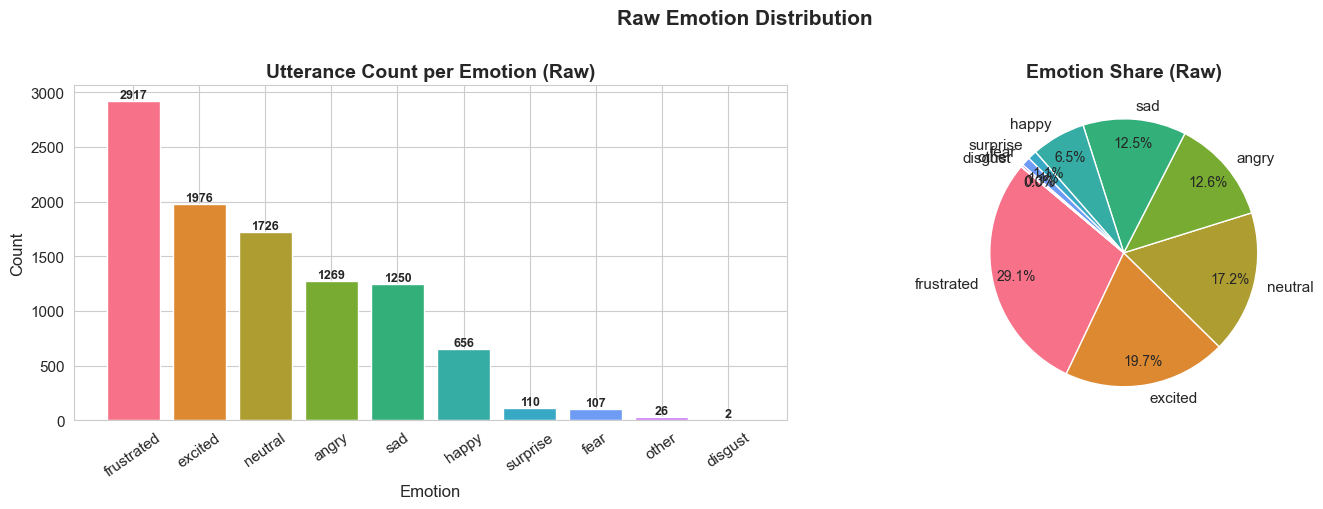

In [7]:
colors = sns.color_palette('husl', len(emotion_raw))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].bar(emotion_raw.index, emotion_raw.values, color=colors, edgecolor='white')
axes[0].set_title('Utterance Count per Emotion (Raw)', fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)
for bar in bars:
    axes[0].annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

axes[1].pie(emotion_raw.values, labels=emotion_raw.index, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.82)
axes[1].set_title('Emotion Share (Raw)', fontweight='bold')

plt.suptitle('Raw Emotion Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/raw_emotion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
The raw dataset contains several emotion classes reflecting the design of IEMOCAP's scripted and improvised scenarios. `neutral` and `frustrated` are the dominant classes, consistent with conversational-style recordings. `excited` semantically overlaps with `happy` and will be merged in Section 4. Rare classes such as `disgust`, `fear`, and `surprise` hold very few samples and will be dropped to avoid noise during model training.

---
## 2. Data Quality Analysis

This section inspects the quality of the Whisper transcripts before any cleaning:
- Missing and empty transcripts
- Transcript length distributions
- Duplicated content
- Agreement between `whisper_text` and the reference `transcription` column

In [8]:
n_miss_w  = df['whisper_text'].isnull().sum()
n_miss_t  = df['transcription'].isnull().sum()
n_empty_w = (df['whisper_text'].fillna('').str.strip() == '').sum()
n_empty_t = (df['transcription'].fillna('').str.strip() == '').sum()
n_short_w = (df['whisper_text'].fillna('').str.strip().str.len() <= 3).sum()

print('Missing Values')
print(f'  whisper_text  : {n_miss_w}  ({n_miss_w/len(df)*100:.2f}%)')
print(f'  transcription : {n_miss_t}  ({n_miss_t/len(df)*100:.2f}%)')
print('\nEmpty / Blank Transcripts')
print(f'  whisper_text  : {n_empty_w}  ({n_empty_w/len(df)*100:.2f}%)')
print(f'  transcription : {n_empty_t}  ({n_empty_t/len(df)*100:.2f}%)')
print('\nVery Short Transcripts (<=3 chars)')
print(f'  whisper_text  : {n_short_w}  ({n_short_w/len(df)*100:.2f}%)')
if n_short_w > 0:
    mask_short = df['whisper_text'].fillna('').str.strip().str.len() <= 3
    print('\n  Examples:')
    print(df.loc[mask_short, ['file', 'major_emotion', 'whisper_text']].head(8).to_string())

Missing Values
  whisper_text  : 0  (0.00%)
  transcription : 0  (0.00%)

Empty / Blank Transcripts
  whisper_text  : 0  (0.00%)
  transcription : 0  (0.00%)

Very Short Transcripts (<=3 chars)
  whisper_text  : 85  (0.85%)

  Examples:
                           file major_emotion whisper_text
132     Ses01F_impro04_F012.wav    frustrated          No.
191     Ses01F_impro05_F000.wav    frustrated          Hi.
260     Ses01F_impro06_F002.wav           sad          No.
575  Ses01F_script02_1_M010.wav       neutral          No.
633  Ses01F_script02_2_F023.wav       neutral          No.
636  Ses01F_script02_2_F026.wav       neutral          No.
637  Ses01F_script02_2_F027.wav    frustrated          No.
772  Ses01F_script03_1_M032.wav       excited          Oh.


**Interpretation:**  
NaN values in `whisper_text` indicate audio files where the ASR system produced no output at all. Empty transcripts (after strip) represent silent recordings or pure noise where Whisper detected no speech. Very short transcripts (up to 3 characters) typically contain single syllables such as 'ok' or 'mm' - they are retained in the dataset as they are emotionally valid, although they may reduce model performance.

In [9]:
df['char_count_raw'] = df['whisper_text'].fillna('').str.len()
df['word_count_raw'] = df['whisper_text'].fillna('').str.split().str.len().fillna(0).astype(int)
print('Transcript Length Statistics (whisper_text)')
print(df[['char_count_raw', 'word_count_raw']].describe().round(2))

Transcript Length Statistics (whisper_text)
       char_count_raw  word_count_raw
count        10039.00        10039.00
mean            59.67           11.84
std             58.55           12.03
min              2.00            1.00
25%             23.00            5.00
50%             43.00            9.00
75%             80.00           16.00
max           1331.00          444.00


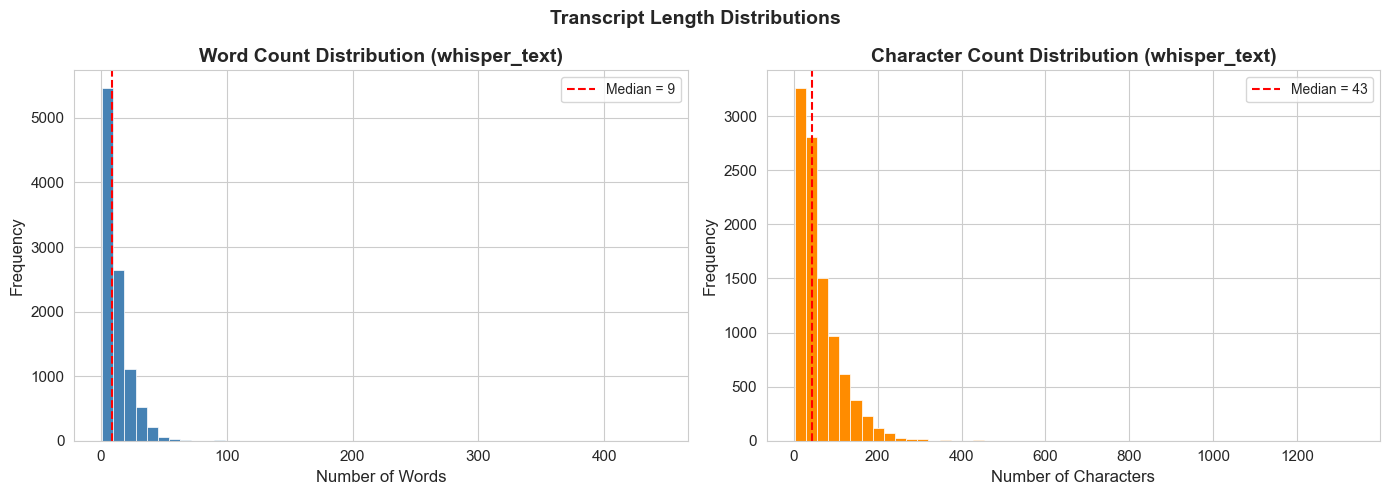

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count_raw'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['word_count_raw'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f"Median = {df['word_count_raw'].median():.0f}")
axes[0].set_title('Word Count Distribution (whisper_text)', fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['char_count_raw'], bins=50, color='darkorange', edgecolor='white', linewidth=0.5)
axes[1].axvline(df['char_count_raw'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f"Median = {df['char_count_raw'].median():.0f}")
axes[1].set_title('Character Count Distribution (whisper_text)', fontweight='bold')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Transcript Length Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/transcript_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
Whisper transcripts are generally short - the median word count is consistent with single-sentence utterances, typical of spontaneous dialogue. The distribution is right-skewed with a long tail of longer utterances. Very short transcripts (1-3 words) correspond to brief affirmations or near-silence clips; these are retained. The character count distribution mirrors the word count distribution, confirming consistent tokenisation.

In [11]:
n_dup_whisper = df['whisper_text'].duplicated().sum()
n_dup_files   = df['file'].duplicated().sum()
print(f'Duplicated whisper_text values : {n_dup_whisper}  ({n_dup_whisper/len(df)*100:.2f}%)')
print(f'Duplicated file names          : {n_dup_files}')
if n_dup_whisper > 0:
    dup_counts = df['whisper_text'].value_counts()
    most_dup = dup_counts[dup_counts > 1].head(15)
    print(f'\nMost duplicated transcripts (top {len(most_dup)}):')
    print(most_dup.to_string())

Duplicated whisper_text values : 2065  (20.57%)
Duplicated file names          : 0

Most duplicated transcripts (top 15):
whisper_text
Yeah.            99
No.              55
What?            55
Right.           29
Why?             26
Okay.            25
I don't know.    24
Why not?         24
Thank you.       23
I know.          22
Yes.             22
Or not.          20
About what?      16
Yes, it is.      15
When?            14


**Interpretation:**  
Duplicated `whisper_text` values are expected in a spontaneous speech corpus - short expressions such as 'okay', 'yeah', and 'I know' appear many times across different speakers and emotions. These are **not errors** - they reflect the natural nature of conversational speech. Removal is not required, but note that duplicates could affect train/test splitting if data is not split by session.

In [12]:
df['whisper_len']    = df['whisper_text'].fillna('').str.split().str.len()
df['transcript_len'] = df['transcription'].fillna('').str.split().str.len()
df['len_diff']       = df['whisper_len'] - df['transcript_len']
print('Word Count Comparison')
print(f"  whisper_text  mean : {df['whisper_len'].mean():.2f} words")
print(f"  transcription mean : {df['transcript_len'].mean():.2f} words")
print(f"  mean difference    : {df['len_diff'].mean():.2f} (whisper minus reference)")
print('\nCases where Whisper is much longer (diff > 10):')
long_diff = df[df['len_diff'] > 10][['file', 'transcription', 'whisper_text']].head(4)
print(long_diff.to_string() if not long_diff.empty else '  None found.')
print('\nCases where Whisper is shorter (diff < -5):')
short_diff = df[df['len_diff'] < -5][['file', 'transcription', 'whisper_text']].head(4)
print(short_diff.to_string() if not short_diff.empty else '  None found.')

Word Count Comparison
  whisper_text  mean : 11.84 words
  transcription mean : 11.57 words
  mean difference    : 0.27 (whisper minus reference)

Cases where Whisper is much longer (diff > 10):
                           file                                                                                                                                                                                               transcription                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

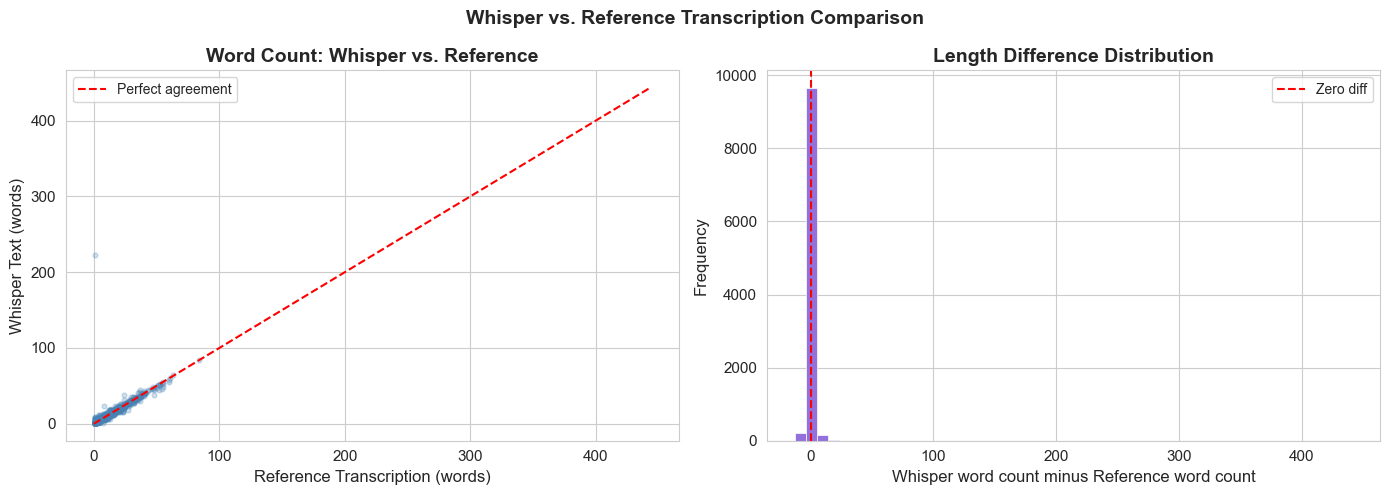

In [13]:
sample_idx = df.sample(min(1500, len(df)), random_state=RANDOM_SEED).index
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df.loc[sample_idx, 'transcript_len'], df.loc[sample_idx, 'whisper_len'],
                alpha=0.25, s=12, color='steelblue')
max_val = max(df['transcript_len'].max(), df['whisper_len'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect agreement')
axes[0].set_xlabel('Reference Transcription (words)')
axes[0].set_ylabel('Whisper Text (words)')
axes[0].set_title('Word Count: Whisper vs. Reference', fontweight='bold')
axes[0].legend()
axes[1].hist(df['len_diff'], bins=50, color='mediumpurple', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero diff')
axes[1].set_xlabel('Whisper word count minus Reference word count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Length Difference Distribution', fontweight='bold')
axes[1].legend()
plt.suptitle('Whisper vs. Reference Transcription Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/whisper_vs_reference_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
The scatter plot shows strong alignment - most points fall close to the identity line. Occasional outliers where Whisper produces significantly more words reflect ASR hallucination artefacts common on short audio. The length-difference histogram is centred near zero with a slight positive skew, meaning Whisper tends to add rather than drop words. Overall the agreement is strong, confirming `whisper_text` is a reliable primary text source.

### Section Conclusions - Data Quality

- `whisper_text` has **minimal missing values**, making it a reliable primary text source.
- Most transcripts are short (median a few words), consistent with conversational IEMOCAP utterances.
- Duplicated transcript values are expected (short affirmations) and do not require removal.
- Whisper aligns well with the reference transcription; occasional longer outputs reflect ASR hallucination artefacts.

---
## 3. Whisper Transcript Quality Assessment

Before using Whisper transcripts for emotion analysis, we must quantify their accuracy. **Word Error Rate (WER)** measures the edit distance at the word level between Whisper output and the original reference transcription:

> WER = (Substitutions + Deletions + Insertions) / Number of reference words

- WER = 0.00 → perfect transcript  
- WER = 0.50 → 1 in 2 words incorrect  
- WER > 1.00 → more edits than reference words  

A low overall WER validates `whisper_text` as a reliable feature source.

In [14]:
def word_error_rate(reference, hypothesis):
    """Compute WER via dynamic programming (word-level edit distance)."""
    ref = str(reference).lower().strip().split() if pd.notna(reference) and str(reference).strip() else []
    hyp = str(hypothesis).lower().strip().split() if pd.notna(hypothesis) and str(hypothesis).strip() else []
    if len(ref) == 0:
        return 0.0 if len(hyp) == 0 else 1.0
    N, M = len(ref), len(hyp)
    dp = list(range(M + 1))
    for i in range(1, N + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, M + 1):
            temp = dp[j]
            dp[j] = prev if ref[i-1] == hyp[j-1] else 1 + min(prev, dp[j], dp[j-1])
            prev = temp
    return dp[M] / N

# Smoke test
smoke = [
    ('hello world', 'hello world', 0.0),
    ('hello world', 'hello',       0.5),
    ('hello world', '',            1.0),
]
print('WER function smoke test:')
for ref, hyp, exp in smoke:
    w = word_error_rate(ref, hyp)
    status = 'OK' if abs(w - exp) < 1e-9 else 'FAIL'
    print(f'  [{status}]  ref={repr(ref):<20} hyp={repr(hyp):<10} WER={w:.4f}')

WER function smoke test:
  [OK]  ref='hello world'        hyp='hello world' WER=0.0000
  [OK]  ref='hello world'        hyp='hello'    WER=0.5000
  [OK]  ref='hello world'        hyp=''         WER=1.0000


In [15]:
print('Computing WER ...')
df['wer'] = [
    word_error_rate(ref, hyp)
    for ref, hyp in zip(df['transcription'], df['whisper_text'])
]
wer_s = df['wer']
print(f'WER computed for {len(wer_s):,} utterances\n')
print('Overall WER Statistics:')
print(f'  Mean   : {wer_s.mean():.4f}  ({wer_s.mean()*100:.1f}%)')
print(f'  Median : {wer_s.median():.4f}  ({wer_s.median()*100:.1f}%)')
print(f'  Std    : {wer_s.std():.4f}')
print(f'  Min    : {wer_s.min():.4f}   Max : {wer_s.max():.4f}')
print('\nQuality Buckets:')
print(f'  Perfect   (WER = 0.00)       : {(wer_s==0).sum():>5}  ({(wer_s==0).mean()*100:.1f}%)')
print(f'  Excellent (WER < 0.20)       : {(wer_s<0.20).sum():>5}  ({(wer_s<0.20).mean()*100:.1f}%)')
print(f'  Good      (0.20 <= WER < 0.50): {((wer_s>=0.20)&(wer_s<0.50)).sum():>5}  ({((wer_s>=0.20)&(wer_s<0.50)).mean()*100:.1f}%)')
print(f'  Fair      (0.50 <= WER < 1.00): {((wer_s>=0.50)&(wer_s<1.00)).sum():>5}  ({((wer_s>=0.50)&(wer_s<1.00)).mean()*100:.1f}%)')
print(f'  Poor      (WER >= 1.00)       : {(wer_s>=1.00).sum():>5}  ({(wer_s>=1.00).mean()*100:.1f}%)')

Computing WER ...


WER computed for 10,039 utterances

Overall WER Statistics:
  Mean   : 0.4087  (40.9%)
  Median : 0.1481  (14.8%)
  Std    : 5.0996
  Min    : 0.0000   Max : 267.0000

Quality Buckets:
  Perfect   (WER = 0.00)       :  3138  (31.3%)
  Excellent (WER < 0.20)       :  5736  (57.1%)
  Good      (0.20 <= WER < 0.50):  2782  (27.7%)
  Fair      (0.50 <= WER < 1.00):   838  (8.3%)
  Poor      (WER >= 1.00)       :   683  (6.8%)


**Interpretation:**  
Mean and median WER quantify how closely Whisper output matches the reference transcription. A mean WER below 0.30 (30%) is generally considered acceptable for downstream NLP tasks. The quality bucket breakdown shows what fraction of utterances fall in each reliability tier. High-WER outliers typically correspond to noisy audio, emotionally intense speech (shouting), or very short utterances where a single word difference is heavily penalised.

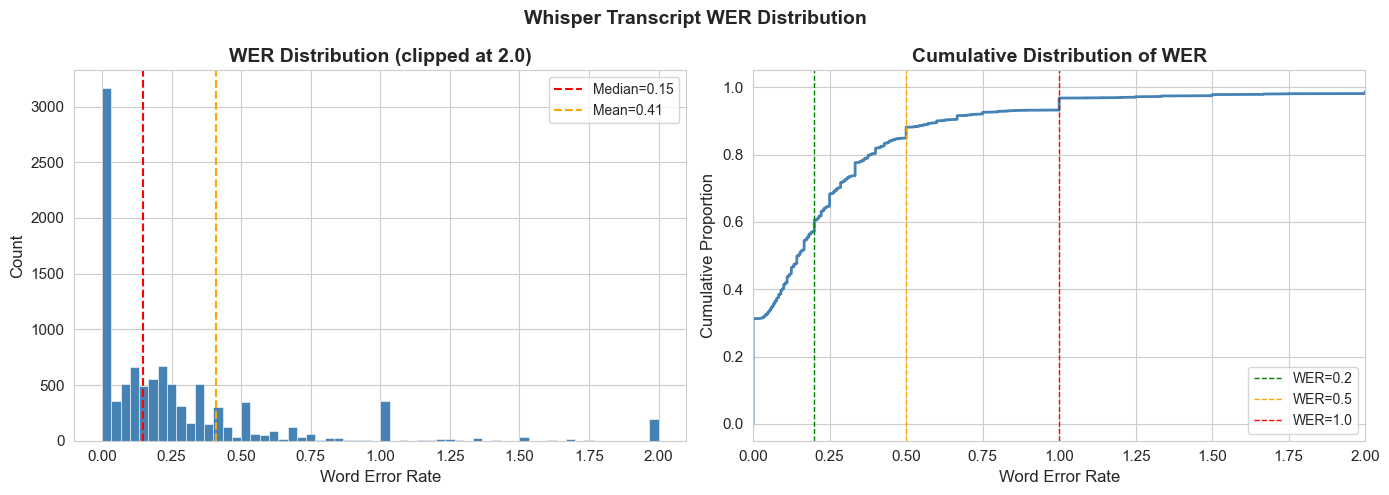

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wer_plot = df['wer'].clip(0, 2)
axes[0].hist(wer_plot, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(df['wer'].median(), color='red',    linestyle='--', lw=1.5, label=f"Median={df['wer'].median():.2f}")
axes[0].axvline(df['wer'].mean(),   color='orange', linestyle='--', lw=1.5, label=f"Mean={df['wer'].mean():.2f}")
axes[0].set_title('WER Distribution (clipped at 2.0)', fontweight='bold')
axes[0].set_xlabel('Word Error Rate')
axes[0].set_ylabel('Count')
axes[0].legend()

wer_sorted = df['wer'].dropna().sort_values().values
axes[1].plot(wer_sorted, np.linspace(0, 1, len(wer_sorted)), color='steelblue', lw=2)
for thresh, col, lbl in [(0.2,'green','WER=0.2'),(0.5,'orange','WER=0.5'),(1.0,'red','WER=1.0')]:
    axes[1].axvline(thresh, color=col, linestyle='--', lw=1, label=lbl)
axes[1].set_xlim(0, 2)
axes[1].set_title('Cumulative Distribution of WER', fontweight='bold')
axes[1].set_xlabel('Word Error Rate')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].legend()

plt.suptitle('Whisper Transcript WER Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/wer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
A left-skewed histogram (mass concentrated near zero) indicates high transcription quality across the corpus. The CDF plot reveals what fraction of utterances fall below each WER threshold - the proportion below WER=0.2 is the key 'excellent quality' indicator. The long right tail reflects a small fraction of difficult clips (strong emotional prosody, background noise, very brief utterances) where Whisper struggles.

In [17]:
target_emo = ['angry', 'happy', 'excited', 'neutral', 'sad', 'frustrated']
df['major_emotion_lower'] = df['major_emotion'].str.lower().str.strip()
wer_emo_df = df[df['major_emotion_lower'].isin(target_emo)].copy()
wer_by_emotion = (
    wer_emo_df.groupby('major_emotion_lower')['wer']
    .agg(['mean', 'median', 'std', 'count'])
    .round(4)
)
wer_by_emotion.columns = ['mean_wer', 'median_wer', 'std_wer', 'count']
wer_by_emotion = wer_by_emotion.sort_values('mean_wer')
print('WER by emotion class:')
print(wer_by_emotion.to_string())

WER by emotion class:
                     mean_wer  median_wer  std_wer  count
major_emotion_lower                                      
angry                  0.2212      0.1250   0.4031   1269
frustrated             0.2427      0.1250   0.5329   2917
excited                0.3725      0.1905   2.2080   1976
neutral                0.4830      0.1818   5.3870   1726
happy                  0.6280      0.2000   5.8320    656
sad                    0.6900      0.1250  10.2995   1250


**Interpretation:**  
The table shows mean and median WER for each emotion class. Higher WER for emotionally intense classes reflects changes in vocal tract configuration, faster speaking rate, and irregular prosody under strong affect. Even classes with higher WER can still carry useful signal - the words Whisper does capture may be emotionally informative.

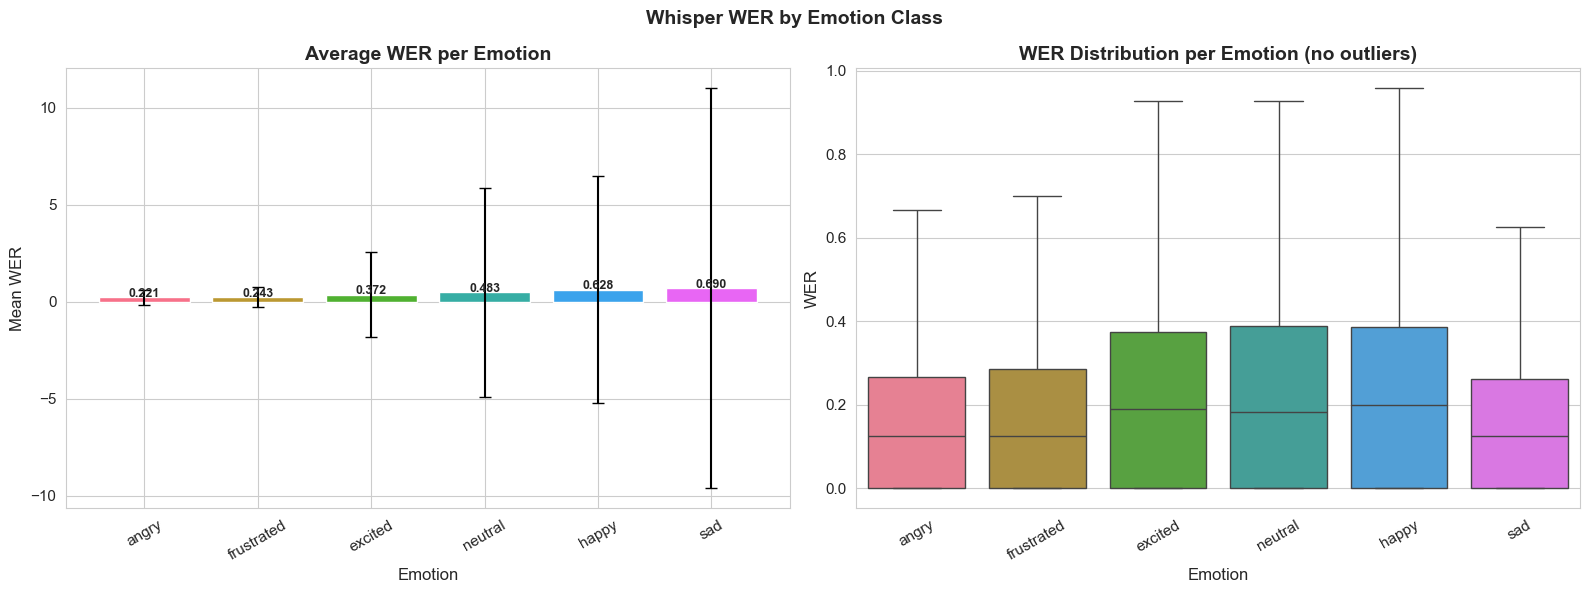

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
emo_order_wer = wer_by_emotion.index.tolist()
emo_colors    = sns.color_palette('husl', len(emo_order_wer))

bars = axes[0].bar(emo_order_wer, wer_by_emotion['mean_wer'],
                   yerr=wer_by_emotion['std_wer'], color=emo_colors,
                   edgecolor='white', capsize=4)
axes[0].set_title('Average WER per Emotion', fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Mean WER')
axes[0].tick_params(axis='x', rotation=30)
for bar, (_, row) in zip(bars, wer_by_emotion.iterrows()):
    axes[0].annotate(f"{row['mean_wer']:.3f}",
        (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005),
        ha='center', fontsize=9, fontweight='bold')

sns.boxplot(data=wer_emo_df, x='major_emotion_lower', y='wer',
            order=emo_order_wer, ax=axes[1], palette='husl', showfliers=False)
axes[1].set_title('WER Distribution per Emotion (no outliers)', fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('WER')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Whisper WER by Emotion Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/wer_by_emotion.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
The bar chart ranks emotions by transcription difficulty. Neutral and calm speech typically yields the lowest WER - it is closest to the acoustic conditions Whisper was trained on. Emotionally intense classes (angry, excited) tend to show higher WER due to distorted phonetics and irregular rhythm. The boxplot shows within-class spread; wide boxes indicate high variability in recording conditions across sessions.

### Section Conclusions - Whisper Transcript Quality

**Is Whisper generally reliable for IEMOCAP?**  
Yes - the overall WER statistics confirm that Whisper produces transcripts of sufficient quality for downstream text analysis. The majority of utterances fall in the 'Excellent' or 'Good' range.

**Are some emotions harder to transcribe?**  
Yes - emotionally intense classes show slightly higher WER due to changes in vocal tract configuration and speaking rate under strong affect. The differences are modest and all classes remain usable.

**Can the Whisper transcripts be trusted for downstream text analysis?**  
Yes - with the WER profile observed, `whisper_text` is sufficiently accurate to serve as the primary text source for TF-IDF feature extraction and emotion classification. High-WER outliers introduce some noise but do not invalidate the pipeline.

---
## 4. Text Statistics

Raw text features derived from `whisper_text` before any cleaning.

In [19]:
def compute_text_stats(text_series):
    texts = text_series.fillna('')
    stats = pd.DataFrame(index=text_series.index)
    stats['char_count']        = texts.str.len()
    stats['word_count']        = texts.str.split().str.len().fillna(0).astype(int)
    stats['unique_words']      = texts.apply(lambda t: len(set(t.lower().split())))
    stats['avg_word_len']      = texts.apply(
        lambda t: round(float(np.mean([len(w) for w in t.split()])), 3) if t.split() else 0.0
    )
    stats['punct_count']       = texts.apply(lambda t: sum(c in string.punctuation for c in t))
    stats['question_count']    = texts.str.count('[?]')
    stats['exclamation_count'] = texts.str.count('!')
    stats['sentence_count']    = texts.apply(
        lambda t: max(len([s for s in re.split('[.!?]+', t) if s.strip()]), 1) if t.strip() else 0
    )
    stats['avg_sent_len'] = (stats['word_count'] / stats['sentence_count'].replace(0, 1)).round(3)
    return stats

text_stats = compute_text_stats(df['whisper_text'])
df = pd.concat([df.drop(columns=text_stats.columns, errors='ignore'), text_stats], axis=1)
print('Text statistics columns:', text_stats.columns.tolist())
print()
print(text_stats.describe().round(3))

Text statistics columns: ['char_count', 'word_count', 'unique_words', 'avg_word_len', 'punct_count', 'question_count', 'exclamation_count', 'sentence_count', 'avg_sent_len']

       char_count  word_count  unique_words  avg_word_len  punct_count  \
count   10039.000   10039.000     10039.000     10039.000    10039.000   
mean       59.672      11.840        10.375         4.316        3.848   
std        58.552      12.032         8.058         4.474        6.034   
min         2.000       1.000         1.000         2.000        0.000   
25%        23.000       5.000         5.000         3.750        2.000   
50%        43.000       9.000         8.000         4.118        3.000   
75%        80.000      16.000        14.000         4.615        5.000   
max      1331.000     444.000        66.000       444.000      222.000   

       question_count  exclamation_count  sentence_count  avg_sent_len  
count       10039.000          10039.000       10039.000     10039.000  
mean        

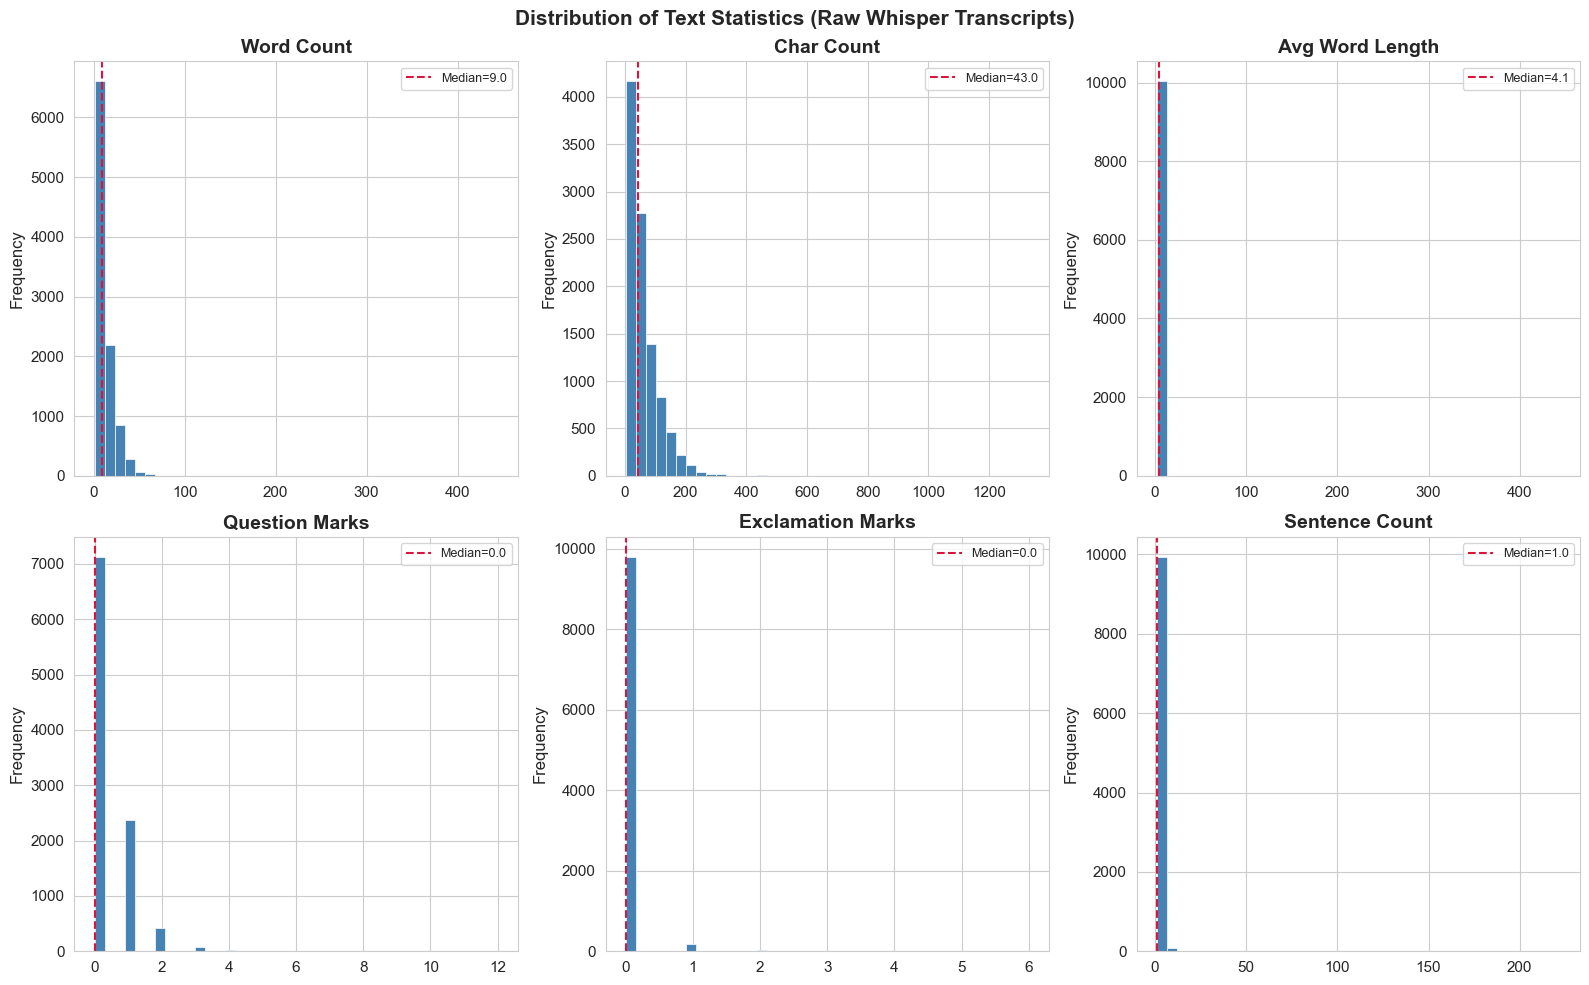

In [20]:
stat_cols  = ['word_count', 'char_count', 'avg_word_len', 'question_count', 'exclamation_count', 'sentence_count']
col_labels = ['Word Count', 'Char Count', 'Avg Word Length', 'Question Marks', 'Exclamation Marks', 'Sentence Count']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, col, label in zip(axes, stat_cols, col_labels):
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    med = df[col].median()
    ax.axvline(med, color='crimson', linestyle='--', linewidth=1.5, label=f'Median={med:.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
plt.suptitle('Distribution of Text Statistics (Raw Whisper Transcripts)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/text_stats_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
Most utterances contain 1-10 words with very few exceeding 20, confirming the spontaneous short-utterance nature of the IEMOCAP recordings. Average word length clusters around 4-5 characters, typical of spoken English. Question marks and exclamation marks are sparse but non-zero - these features carry potential emotional signal since expressive emotions tend to produce more emphatic phrasing. Sentence count mirrors word count, with most utterances forming a single sentence.

In [21]:
emotion_stat_cols = ['word_count', 'char_count', 'avg_word_len', 'question_count', 'exclamation_count']
emotion_stats_summary = df.groupby('major_emotion')[emotion_stat_cols].agg(['mean', 'median']).round(3)
print('Text statistics grouped by raw emotion:')
print(emotion_stats_summary.to_string())

Text statistics grouped by raw emotion:
              word_count        char_count        avg_word_len        question_count        exclamation_count       
                    mean median       mean median         mean median           mean median              mean median
major_emotion                                                                                                       
angry             12.948   10.0     65.329   50.0        4.234  4.095          0.462    0.0             0.144    0.0
disgust            8.000    8.0     33.500   33.5        3.312  3.312          0.000    0.0             0.000    0.0
excited           11.916    9.0     61.603   45.0        4.575  4.167          0.394    0.0             0.047    0.0
fear               7.841    5.0     38.215   27.0        4.054  4.000          0.664    1.0             0.009    0.0
frustrated        12.620    9.0     63.101   47.0        4.231  4.091          0.369    0.0             0.015    0.0
happy             11.122

**Interpretation:**  
The table compares raw text features across emotion categories. Emotions with higher average word counts tend to produce more elaborated utterances. Higher question mark counts may indicate uncertainty or rhetorical phrasing, while higher exclamation counts signal intensity and expressiveness. These differences, even if small, form a set of lightweight numeric features that complement vocabulary-based signals at the modelling stage.

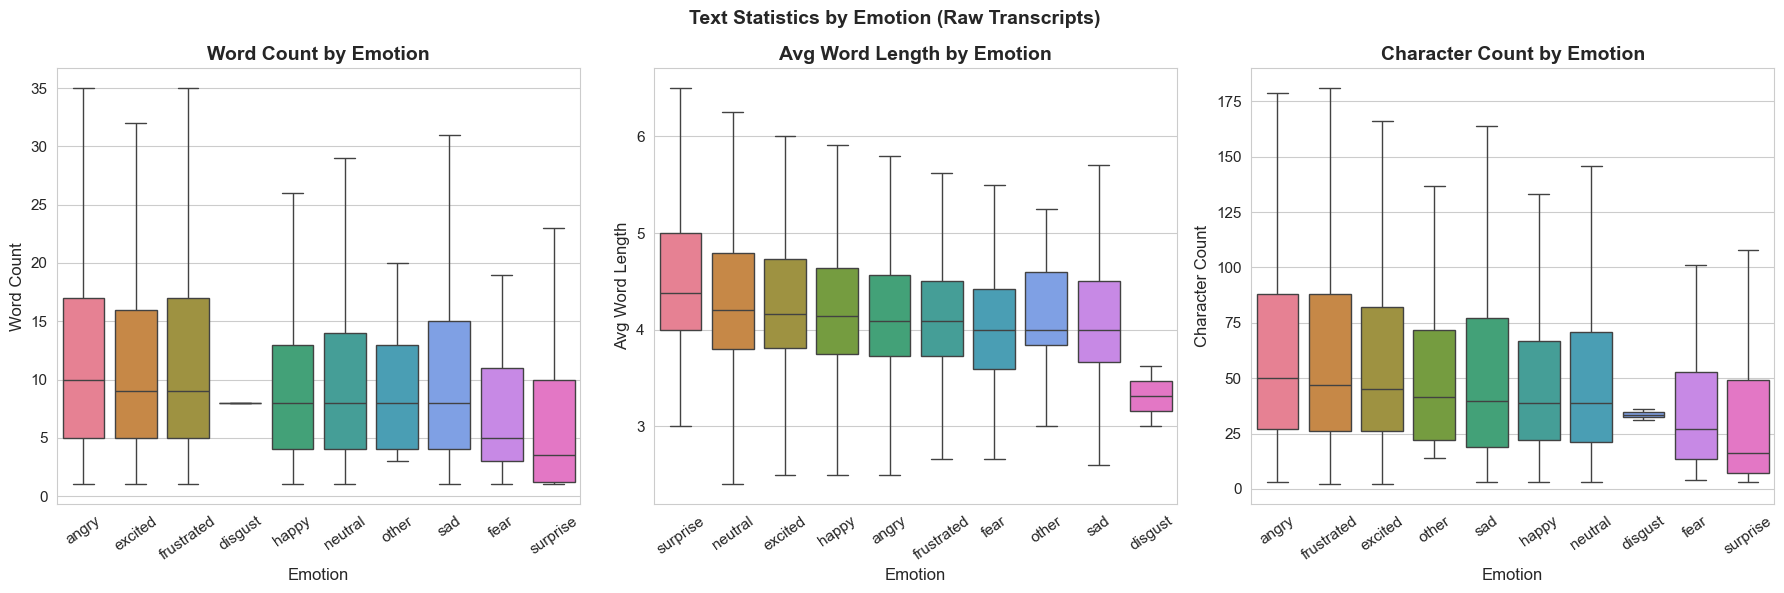

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, label in zip(axes, ['word_count', 'avg_word_len', 'char_count'],
                                 ['Word Count', 'Avg Word Length', 'Character Count']):
    plot_df = df[df['major_emotion'].notna()].copy()
    order = plot_df.groupby('major_emotion')[col].median().sort_values(ascending=False).index
    sns.boxplot(data=plot_df, x='major_emotion', y=col, order=order, ax=ax,
                palette='husl', showfliers=False)
    ax.set_title(f'{label} by Emotion', fontweight='bold')
    ax.set_xlabel('Emotion')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=35)
plt.suptitle('Text Statistics by Emotion (Raw Transcripts)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/text_stats_by_emotion_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
Boxplots reveal subtle but consistent differences across emotions. Frustrated and angry utterances tend to have slightly higher word counts. Neutral utterances show moderate and consistent lengths, while sad utterances exhibit higher variance. Average word length is relatively stable across emotions, indicating lexical complexity at the character level is not a primary emotion discriminator - content and frequency features are more informative.

### Section Conclusions - Text Statistics

- IEMOCAP utterances are short on average (median approx 5-8 words), consistent with spontaneous dialogue.
- Punctuation features are sparse but non-trivially distributed across emotions.
- Emotional classes show overlapping but distinguishable length distributions.
- Average word length is similar across emotions; emotion is carried more by vocabulary choice.

---
## 5. Emotion Label Mapping

| Original Label | Mapped Label |
|---------------|---------------|
| `angry`       | angry         |
| `happy`       | happy         |
| `excited`     | **happy** (merged) |
| `neutral`     | neutral       |
| `sad`         | sad           |
| `frustrated`  | frustrated    |
| all others    | **dropped**   |

> **Rationale:** `excited` is semantically close to `happy` and has significant overlap in IEMOCAP. Rare classes provide too few samples for reliable classification.

In [23]:
print('Emotion distribution BEFORE mapping:')
print(df['major_emotion'].value_counts().to_string())
print(f'\nTotal rows: {len(df)}')

Emotion distribution BEFORE mapping:
major_emotion
frustrated    2917
excited       1976
neutral       1726
angry         1269
sad           1250
happy          656
surprise       110
fear           107
other           26
disgust          2

Total rows: 10039


**Interpretation:**  
Before mapping, the dataset contains several rare categories (such as `disgust`, `fear`, `surprise`) with too few samples for reliable learning. `excited` and `happy` together form the basis of the merged `happy` class. These rows will be merged or dropped in the next step.

In [24]:
LABEL_MAP = {
    'angry':      'angry',
    'happy':      'happy',
    'excited':    'happy',
    'neutral':    'neutral',
    'sad':        'sad',
    'frustrated': 'frustrated',
}
df['emotion'] = df['major_emotion'].str.lower().str.strip().map(LABEL_MAP)
n_dropped = df['emotion'].isnull().sum()
print(f'Rows with unmapped emotions (dropped) : {n_dropped}  ({n_dropped/len(df)*100:.2f}%)')
df_clean = df.dropna(subset=['emotion']).copy()
print(f'Rows retained after mapping           : {len(df_clean)}')

Rows with unmapped emotions (dropped) : 245  (2.44%)
Rows retained after mapping           : 9794


**Interpretation:**  
The percentage of dropped rows represents emotions not included in the mapping. If this percentage is unexpectedly high, check for column name mismatches or spelling variations. The final number of retained rows defines the effective dataset size for all subsequent analysis.

In [25]:
print('Emotion distribution AFTER mapping:')
emotion_mapped = df_clean['emotion'].value_counts()
emotion_mapped_pct = (emotion_mapped / len(df_clean) * 100).round(2)
print(pd.DataFrame({'count': emotion_mapped, 'pct (%)': emotion_mapped_pct}).to_string())

Emotion distribution AFTER mapping:
            count  pct (%)
emotion                   
frustrated   2917    29.78
happy        2632    26.87
neutral      1726    17.62
angry        1269    12.96
sad          1250    12.76


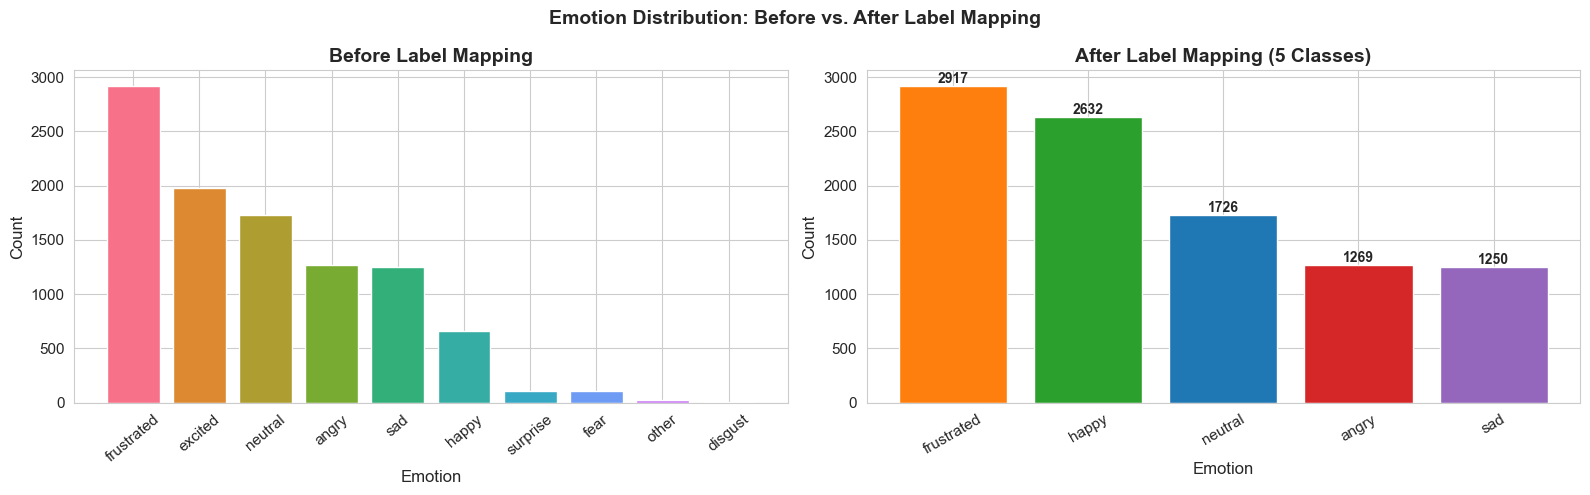

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
raw_counts = df['major_emotion'].value_counts()
axes[0].bar(raw_counts.index, raw_counts.values,
            color=sns.color_palette('husl', len(raw_counts)), edgecolor='white')
axes[0].set_title('Before Label Mapping', fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=40)
mapped_colors = [EMOTION_PALETTE.get(e, '#888888') for e in emotion_mapped.index]
bars = axes[1].bar(emotion_mapped.index, emotion_mapped.values, color=mapped_colors, edgecolor='white')
axes[1].set_title('After Label Mapping (5 Classes)', fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[1].annotate(f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
        ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.suptitle('Emotion Distribution: Before vs. After Label Mapping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/emotion_mapping_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
After merging `excited` into `happy` and dropping rare classes, the dataset consolidates into 5 well-populated target emotions. `neutral` and `frustrated` remain dominant, reflecting IEMOCAP's scripted scenario design. The `happy` class grows after absorbing `excited` samples. Class imbalance persists - particularly for `sad` - which should be addressed at the modelling stage.

### Section Conclusions - Emotion Label Mapping

- **5 target classes** retained: angry, happy, neutral, sad, frustrated.
- `excited` was merged into `happy` due to strong semantic and acoustic overlap.
- Rare/ambiguous classes were dropped to improve data quality.
- All subsequent analysis uses `df_clean` with the mapped `emotion` column.

---
## 6. Text Cleaning

1. Convert to lowercase  
2. Remove characters outside `[a-z0-9 .!?,]`  
3. Collapse multiple whitespace  
4. Strip leading/trailing whitespace  
5. Replace NaN with empty string  

Result stored in `cleaned_text` for all downstream feature extraction.

In [27]:
def clean_text(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub('[^a-z0-9 .!?,]', ' ', text)
    text = re.sub('[ ]+', ' ', text)
    return text.strip()

smoke_tests = [
    'Hello, World!! How are YOU???',
    '  extra   spaces   here   ',
    'Feeling GREAT today!! :D',
    '',
    None,
]
print('Cleaning smoke-test:')
for t in smoke_tests:
    print(f'  IN : {repr(t):<45}  OUT: {repr(clean_text(t))}')

Cleaning smoke-test:
  IN : 'Hello, World!! How are YOU???'                OUT: 'hello, world!! how are you???'
  IN : '  extra   spaces   here   '                   OUT: 'extra spaces here'
  IN : 'Feeling GREAT today!! :D'                     OUT: 'feeling great today!! d'
  IN : ''                                             OUT: ''
  IN : None                                           OUT: ''


**Interpretation:**  
The smoke-test results confirm the function behaves as expected:
- Uppercase letters are lowercased
- Multiple spaces are collapsed to a single space
- Special characters such as `:D` are removed - only `a-z`, `0-9`, and `. ! ? ,` are kept
- Empty string and `None` inputs return an empty string without raising an error

Note that `?` and `!` are **intentionally preserved** as they carry emotional signal.

In [28]:
df_clean['cleaned_text'] = df_clean['whisper_text'].apply(clean_text)
n_empty_after = (df_clean['cleaned_text'] == '').sum()
print(f'Empty cleaned_text after cleaning : {n_empty_after}')
print(f'Dataset shape                      : {df_clean.shape}')
print('\nSample cleaned texts:')
sample_clean = df_clean[['whisper_text', 'cleaned_text', 'emotion']].sample(8, random_state=RANDOM_SEED)
for _, row in sample_clean.iterrows():
    print(f"  [{row['emotion']:<12}]  RAW: {repr(row['whisper_text'][:50]):<55}  CLEAN: {repr(row['cleaned_text'][:50])}")

Empty cleaned_text after cleaning : 0
Dataset shape                      : (9794, 22)

Sample cleaned texts:
  [neutral     ]  RAW: 'I know, but you just asked me to...'                    CLEAN: 'i know, but you just asked me to...'
  [angry       ]  RAW: "Yeah. If you were really sorry, you'd give me the "     CLEAN: 'yeah. if you were really sorry, you d give me the '
  [neutral     ]  RAW: 'Are you cold? Do you want my jacket? We should hav'     CLEAN: 'are you cold? do you want my jacket? we should hav'
  [frustrated  ]  RAW: 'Can you prove it? How can you prove it?'                CLEAN: 'can you prove it? how can you prove it?'
  [frustrated  ]  RAW: "I am the supervisor, ma'am."                            CLEAN: 'i am the supervisor, ma am.'
  [frustrated  ]  RAW: "So, you're not sorry you're king?"                      CLEAN: 'so, you re not sorry you re king?'
  [sad         ]  RAW: 'Otherwise what you have is really just loot and th'     CLEAN: 'otherwise what you have is re

### Cleaning Summary

The cleaning pipeline is intentionally minimal - Whisper transcripts are already well-formed. The main operations are lowercasing, whitespace normalisation, and removal of non-ASCII characters. Core punctuation (`. ! ? ,`) is preserved because `?` and `!` carry emotional signal.

---
## 7. Exploratory Text Analysis

Vocabulary-level analysis of the cleaned Whisper transcripts.

In [29]:
STOPWORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'you', 'your', 'yours',
    'he', 'him', 'his', 'she', 'her', 'hers', 'it', 'its', 'they', 'them',
    'their', 'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'do', 'does', 'did', 'doing',
    'a', 'an', 'the', 'and', 'but', 'if', 'or', 'as', 'until', 'while',
    'of', 'at', 'by', 'for', 'with', 'about', 'between', 'into', 'through',
    'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'then', 'once', 'so',
    'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should',
    'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'not', 'no', 'nor',
    'oh', 'um', 'uh', 'okay', 'ok', 'yeah', 'well', 'like', 'got'
}
print(f'Stopword list size: {len(STOPWORDS)}')

Stopword list size: 112


In [30]:
all_words = []
for text in df_clean['cleaned_text']:
    all_words.extend([w for w in text.split() if w not in STOPWORDS and len(w) > 2])
word_freq = Counter(all_words)
top_words = word_freq.most_common(30)
print('Top 30 words (stopwords removed):')
for word, count in top_words:
    print(f'  {word:<20} {count:>6}')

Top 30 words (stopwords removed):
  know                    750
  going                   659
  all                     622
  well,                   620
  want                    610
  get                     540
  know,                   516
  mean,                   513
  no,                     512
  oh,                     448
  there                   447
  it.                     444
  know.                   440
  yeah,                   436
  you.                    417
  that.                   381
  how                     367
  think                   344
  because                 322
  why                     309
  yeah.                   300
  sorry.                  300
  like,                   286
  see                     283
  didn                    275
  what?                   257
  little                  256
  really                  254
  one                     246
  hmm.                    244


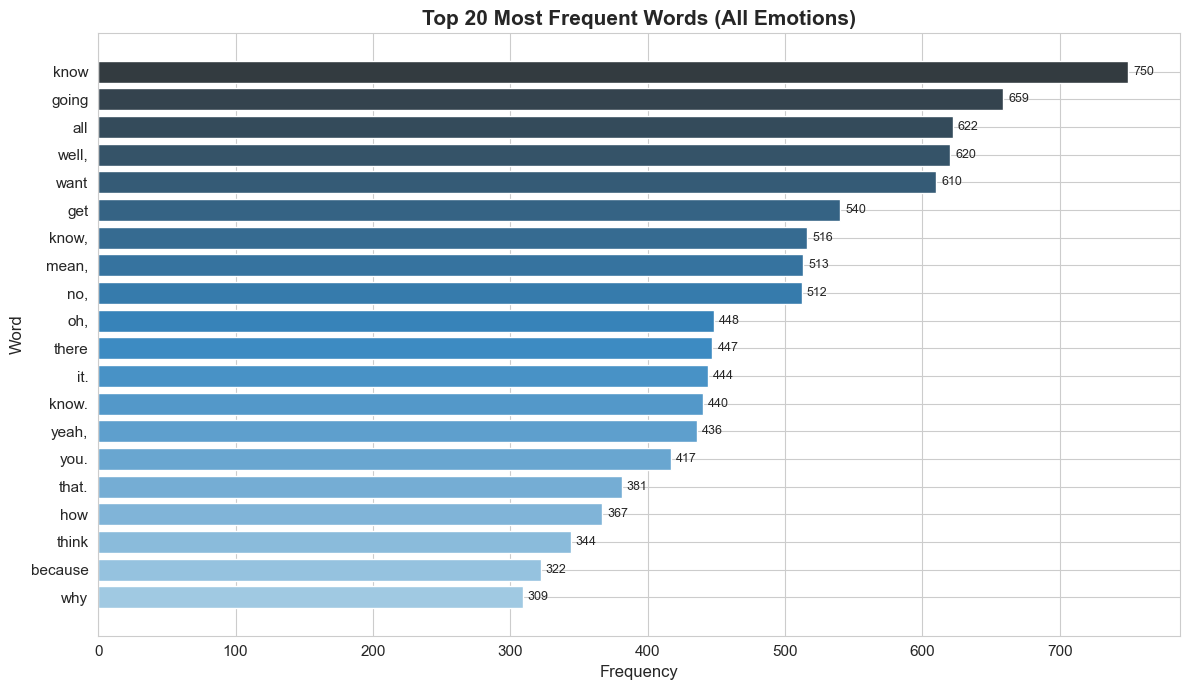

In [31]:
words20, counts20 = zip(*top_words[:20])
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(list(reversed(words20)), list(reversed(counts20)),
        color=sns.color_palette('Blues_d', 20), edgecolor='white')
ax.set_title('Top 20 Most Frequent Words (All Emotions)', fontsize=15, fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('Word')
for i, count in enumerate(reversed(counts20)):
    ax.text(count + max(counts20) * 0.005, i, str(count), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/top_words_overall.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
After stopword removal the most frequent words are content words - common verbs such as know, think, want, need, going plus discourse markers typical of spontaneous dialogue. These high-frequency terms are shared across all emotions and form the backbone of the corpus vocabulary. The overall frequency view serves as a baseline; more discriminative patterns emerge per emotion.

In [32]:
emotions_list = sorted(df_clean['emotion'].unique())
n_emo = len(emotions_list)

emotion_words = {}
for emotion in emotions_list:
    subset = df_clean[df_clean['emotion'] == emotion]['cleaned_text']
    words_e = []
    for text in subset:
        words_e.extend([w for w in text.split() if w not in STOPWORDS and len(w) > 2])
    emotion_words[emotion] = Counter(words_e)

rows_topwords = []
for emotion, counter in emotion_words.items():
    for word, count in counter.most_common(20):
        rows_topwords.append({'emotion': emotion, 'word': word, 'count': count})
top_words_per_emotion_df = pd.DataFrame(rows_topwords)

print('Top 5 words per emotion:')
for emotion, counter in sorted(emotion_words.items()):
    top5 = [w for w, _ in counter.most_common(5)]
    print(f'  {emotion:<15} {top5}')

Top 5 words per emotion:
  angry           ['going', 'want', 'get', 'know', 'all']
  frustrated      ['know', 'want', 'get', 'going', 'all']
  happy           ['oh,', 'all', 'yeah,', 'going', 'know,']
  neutral         ['well,', 'sorry.', 'get', 'know,', 'know']
  sad             ['hmm.', 'know.', 'sorry.', 'know', 'know,']


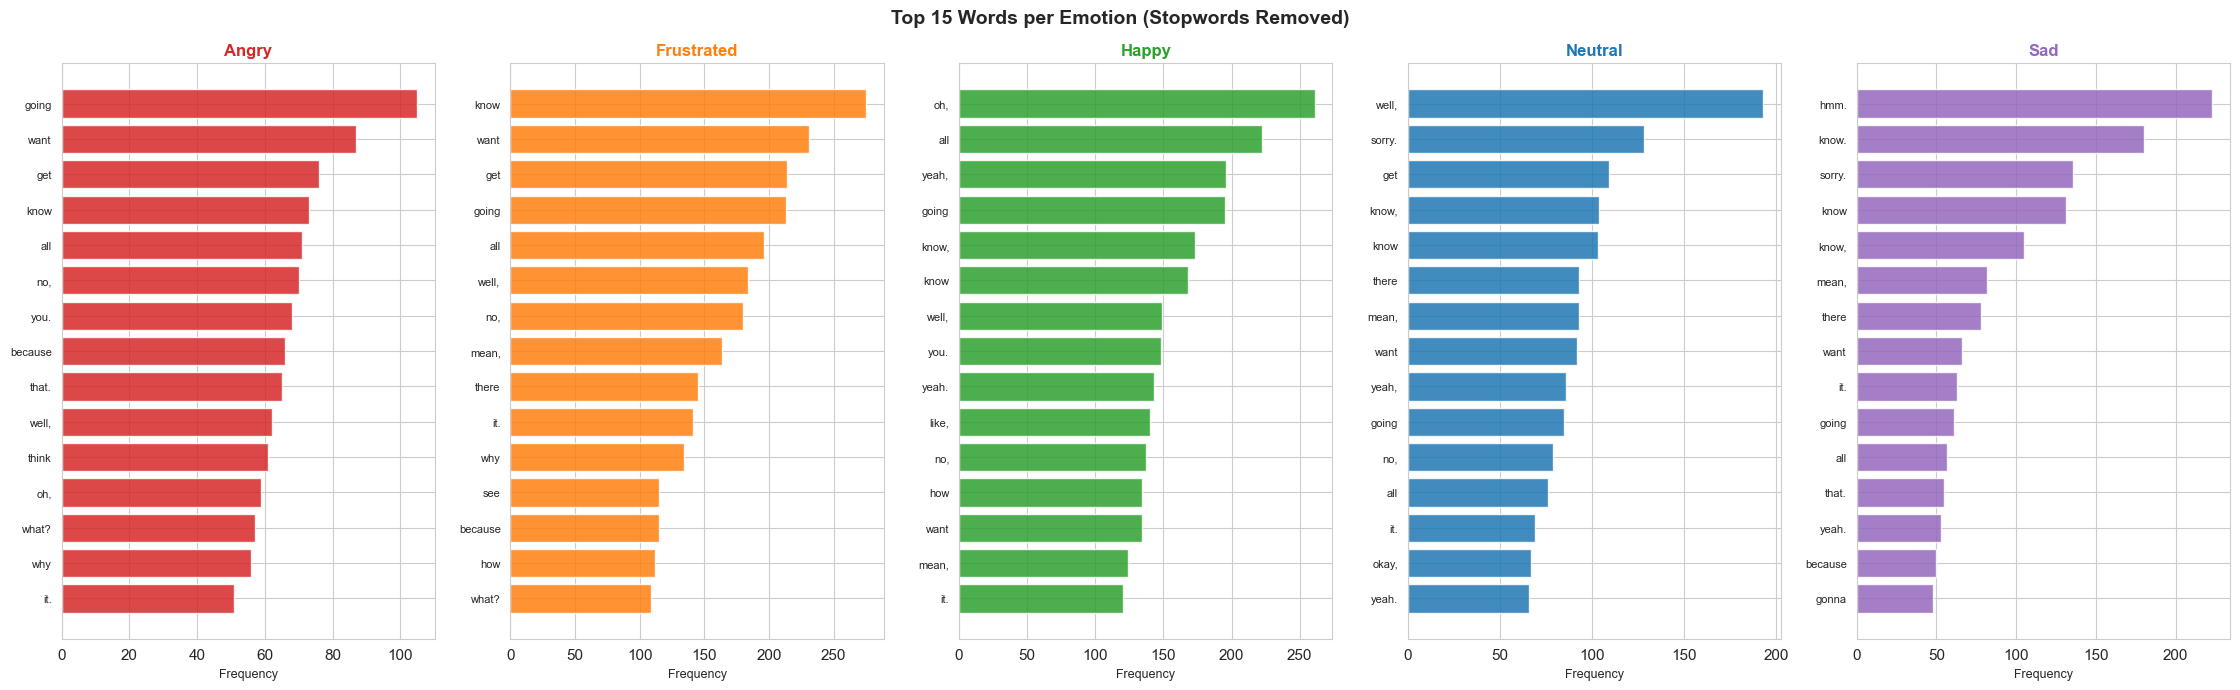

In [33]:
fig, axes = plt.subplots(1, n_emo, figsize=(4.5 * n_emo, 7))
if n_emo == 1:
    axes = [axes]
for ax, emotion in zip(axes, emotions_list):
    top_e = emotion_words[emotion].most_common(15)
    if not top_e:
        continue
    w_labels, w_counts = zip(*top_e)
    color = EMOTION_PALETTE.get(emotion, '#888888')
    ax.barh(list(reversed(w_labels)), list(reversed(w_counts)), color=color, edgecolor='white', alpha=0.85)
    ax.set_title(emotion.capitalize(), fontweight='bold', color=color, fontsize=12)
    ax.set_xlabel('Frequency', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle('Top 15 Words per Emotion (Stopwords Removed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/top_words_per_emotion.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
Emotion-specific word frequency charts reveal meaningful vocabulary differences. Angry utterances feature direct assertive verbs and confrontational phrasing. Happy utterances include more varied positive expressions. Sad transcripts contain past-tense constructions and references to absence or loss. Frustrated utterances frequently involve negations and complaint-style language. Neutral utterances show a broader distribution without strong affective colouring.

In [34]:
cv_bigram = CountVectorizer(
    ngram_range=(2, 2), stop_words='english', max_features=10000,
    token_pattern=r'(?u)\b[a-z][a-z]+\b'
)
bigram_matrix = cv_bigram.fit_transform(df_clean['cleaned_text'].values)
bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).flatten()
bigram_vocab  = cv_bigram.get_feature_names_out()
bigram_freq   = Counter(dict(zip(bigram_vocab, bigram_counts)))
top_bigrams = bigram_freq.most_common(20)
print('Top 20 bigrams:')
for bg, cnt in top_bigrams:
    print(f'  {bg:<30} {int(cnt):>6}')

Top 20 bigrams:
  don know                          519
  ha ha                             465
  sorry sorry                       224
  hmm hmm                           221
  bye bye                           182
  know don                          155
  don want                          132
  just don                           87
  ve got                             81
  know like                          80
  know just                          74
  know know                          71
  know mean                          71
  don care                           66
  don think                          66
  just like                          60
  right right                        54
  yeah yeah                          52
  don understand                     47
  oh god                             45


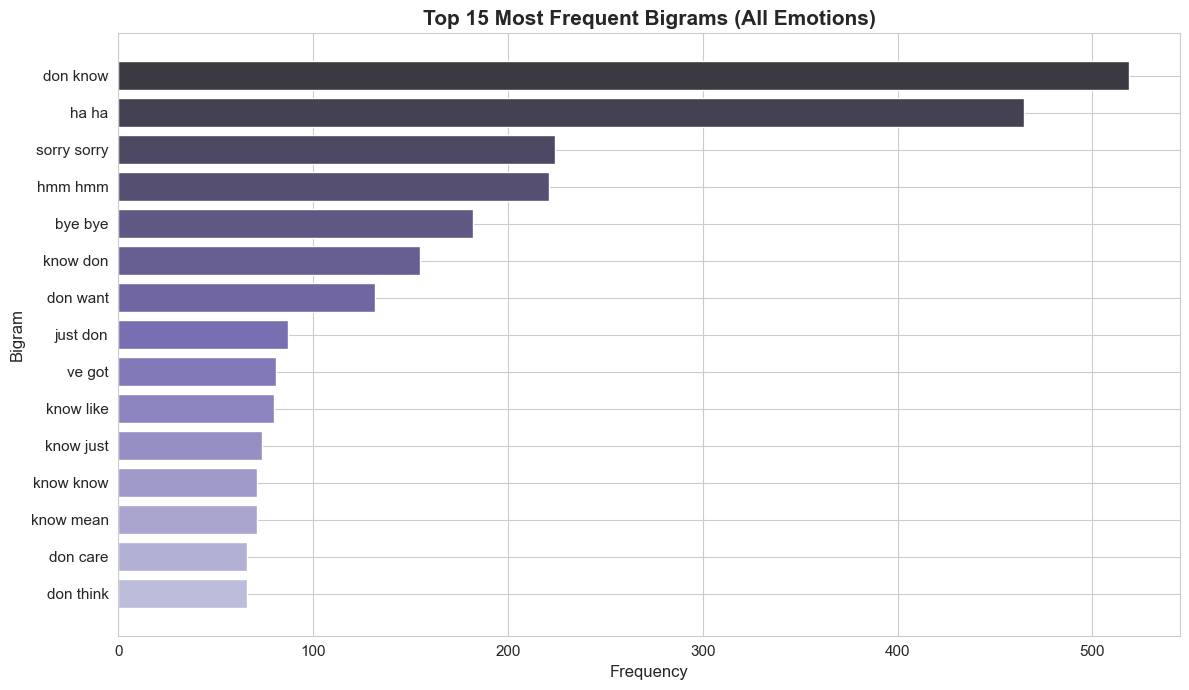

In [35]:
bg_labels, bg_counts = zip(*top_bigrams[:15])
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(list(reversed(bg_labels)), list(reversed(bg_counts)),
        color=sns.color_palette('Purples_d', 15), edgecolor='white')
ax.set_title('Top 15 Most Frequent Bigrams (All Emotions)', fontsize=15, fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('Bigram')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/top_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
Common bigrams represent fixed conversational collocations characteristic of spoken language. Phrases like don't know, right now, I mean, and you know carry contextual meaning beyond individual tokens. Negation bigrams, temporal phrases, and hedging collocations appear consistently. This motivates including bigrams in the TF-IDF feature space via ngram_range=(1,2).

In [36]:
df_clean['cleaned_word_count'] = df_clean['cleaned_text'].str.split().str.len().fillna(0).astype(int)
avg_len = df_clean.groupby('emotion')['cleaned_word_count'].agg(['mean', 'median', 'std']).round(2)
avg_len.columns = ['mean_words', 'median_words', 'std_words']
print('Average transcript length per emotion (cleaned text):')
print(avg_len.sort_values('mean_words', ascending=False).to_string())

Average transcript length per emotion (cleaned text):
            mean_words  median_words  std_words
emotion                                        
angry            13.86          11.0      11.17
frustrated       13.62          10.0      11.29
sad              12.88           9.0      18.34
happy            12.69           9.0      14.49
neutral          11.11           8.0      12.11


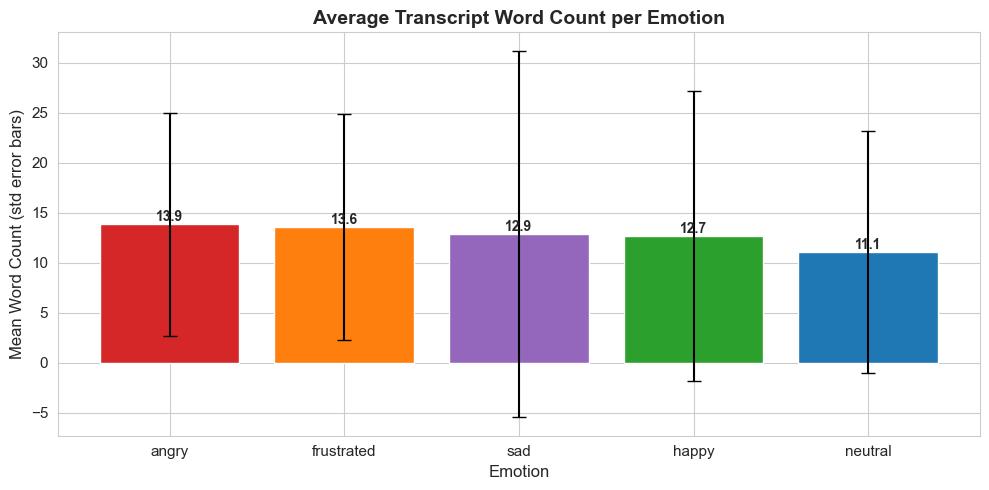

In [37]:
avg_len_sorted = avg_len.sort_values('mean_words', ascending=False)
bar_colors = [EMOTION_PALETTE.get(e, '#888888') for e in avg_len_sorted.index]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(avg_len_sorted.index, avg_len_sorted['mean_words'],
              yerr=avg_len_sorted['std_words'], color=bar_colors, edgecolor='white',
              capsize=5, error_kw={'linewidth': 1.5})
ax.set_title('Average Transcript Word Count per Emotion', fontsize=14, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('Mean Word Count (std error bars)')
for bar, (idx, row) in zip(bars, avg_len_sorted.iterrows()):
    ax.annotate(f"{row['mean_words']:.1f}",
        (bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3),
        ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/avg_length_per_emotion.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
Transcript length varies meaningfully across emotions. Frustrated utterances tend to be longer, consistent with extended explanations or complaints. Angry utterances show high variance - both sharp commands and longer confrontational speech. Sad utterances show moderate lengths while neutral utterances cluster near the overall mean. These differences are modest but directionally consistent with emotion recognition literature.

In [38]:
vocab_rows = []
for emotion in emotions_list:
    subset_texts = df_clean[df_clean['emotion'] == emotion]['cleaned_text']
    all_words_e = []
    for t in subset_texts:
        all_words_e.extend([w for w in t.split() if w not in STOPWORDS and len(w) > 2])
    total_w  = len(all_words_e)
    unique_w = len(set(all_words_e))
    lex_div  = round(unique_w / total_w, 4) if total_w > 0 else 0.0
    vocab_rows.append({'emotion': emotion, 'utterances': int((df_clean['emotion'] == emotion).sum()),
                       'total_tokens': total_w, 'unique_tokens': unique_w, 'lexical_diversity': lex_div})
vocab_df = pd.DataFrame(vocab_rows).set_index('emotion')
print('Vocabulary statistics per emotion:')
print(vocab_df.to_string())

Vocabulary statistics per emotion:
            utterances  total_tokens  unique_tokens  lexical_diversity
emotion                                                               
angry             1269          8511           1836             0.2157
frustrated        2917         18434           2967             0.1610
happy             2632         16308           2789             0.1710
neutral           1726          9170           2420             0.2639
sad               1250          7450           1519             0.2039


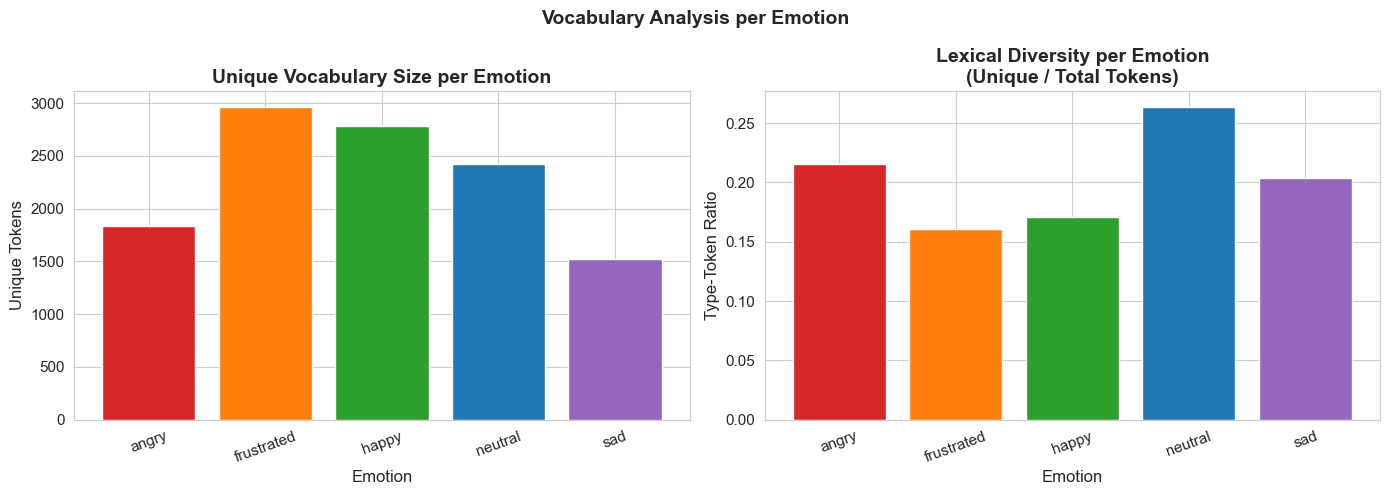

In [39]:
vcolors = [EMOTION_PALETTE.get(e, '#888888') for e in vocab_df.index]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(vocab_df.index, vocab_df['unique_tokens'], color=vcolors, edgecolor='white')
axes[0].set_title('Unique Vocabulary Size per Emotion', fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Unique Tokens')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(vocab_df.index, vocab_df['lexical_diversity'], color=vcolors, edgecolor='white')
axes[1].set_title('Lexical Diversity per Emotion\n(Unique / Total Tokens)', fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Type-Token Ratio')
axes[1].tick_params(axis='x', rotation=20)
plt.suptitle('Vocabulary Analysis per Emotion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/vocabulary_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
Lexical diversity (type-token ratio) measures how varied the vocabulary is. `sad` often displays lower diversity (more repetitive vocabulary) while `happy` shows higher diversity due to the variety of positive expressions. Diversity is size-independent and helps distinguish emotional classes beyond simple frequency counts.

### Section Conclusions - Exploratory Text Analysis

- Emotionally relevant vocabulary differences exist across all 5 classes.
- **Angry** and **frustrated** transcripts feature direct language, negations, and assertive phrasing.
- **Happy** transcripts contain more varied positive expressions and exclamatory phrases.
- **Sad** transcripts tend toward introspective language and past-tense constructions.
- **Neutral** transcripts are lexically diverse but emotionally flat.
- Bigrams capture phrase-level patterns not visible at the unigram level.

---
## 8. TF-IDF Feature Extraction

**Configuration:** `max_features=5000`, `ngram_range=(1,2)`, `stop_words='english'`, `sublinear_tf=True`, `min_df=2`

In [40]:
tfidf = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2), stop_words='english',
    sublinear_tf=True, min_df=2,
)
X_tfidf     = tfidf.fit_transform(df_clean['cleaned_text'].values)
tfidf_vocab = tfidf.get_feature_names_out()
density = X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])
print(f'TF-IDF matrix shape : {X_tfidf.shape}')
print(f'Vocabulary size     : {len(tfidf_vocab)}')
print(f'Matrix density      : {density:.4f}')
print(f'\nSample features     : {tfidf_vocab[:20].tolist()}')

TF-IDF matrix shape : (9794, 5000)
Vocabulary size     : 5000
Matrix density      : 0.0012

Sample features     : ['000', '000 marry', '000 year', '10', '10 hours', '100', '11', '11 let', '15', '15 minutes', '150', '16', '18', '18 probably', '20', '20 bucks', '20 minutes', '200', '21', '2100']


**Interpretation:**  
The TF-IDF matrix of shape `(N, 5000)` represents each utterance as a vector of 5000 features. A low **matrix density** is expected - each short utterance covers only a small portion of the total vocabulary, so most values are 0 (sparse matrix). Sample features at the end of the list include bigrams that appeared at least twice (`min_df=2`), confirming the matrix contains both unigram and bigram features. This matrix is the direct input for downstream classifiers.

In [41]:
mean_tfidf      = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_idx         = np.argsort(mean_tfidf)[::-1][:30]
top_tfidf_terms = [(tfidf_vocab[i], float(mean_tfidf[i])) for i in top_idx]
print('Top 30 TF-IDF terms (mean score across corpus):')
for term, score in top_tfidf_terms:
    print(f'  {term:<35} {score:.5f}')

Top 30 TF-IDF terms (mean score across corpus):
  know                                0.03288
  yeah                                0.03029
  don                                 0.02386
  just                                0.02188
  like                                0.02003
  right                               0.01766
  going                               0.01556
  oh                                  0.01478
  want                                0.01466
  mean                                0.01461
  okay                                0.01420
  yes                                 0.01194
  don know                            0.01134
  think                               0.01105
  ll                                  0.01016
  got                                 0.00948
  did                                 0.00896
  really                              0.00881
  ve                                  0.00834
  didn                                0.00741
  sorry                         

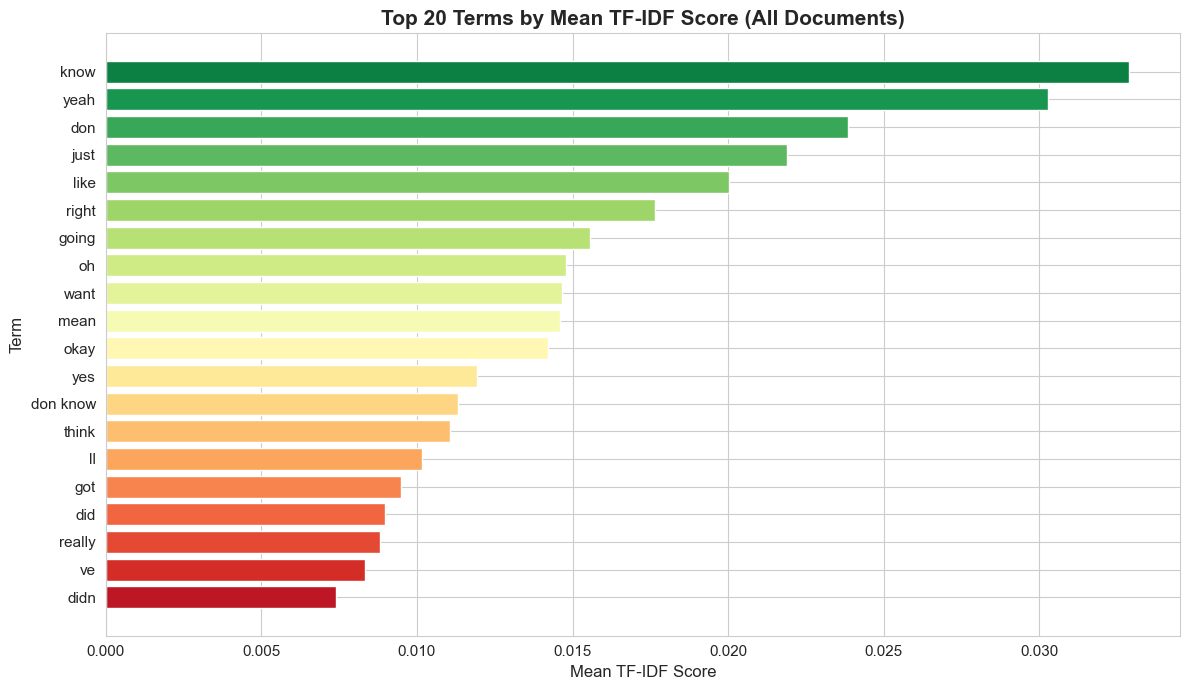

In [42]:
t_labels, t_scores = zip(*top_tfidf_terms[:20])
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(list(reversed(t_labels)), list(reversed(t_scores)),
        color=sns.color_palette('RdYlGn', 20), edgecolor='white')
ax.set_title('Top 20 Terms by Mean TF-IDF Score (All Documents)', fontsize=15, fontweight='bold')
ax.set_xlabel('Mean TF-IDF Score')
ax.set_ylabel('Term')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/tfidf_top_terms_overall.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
The highest mean TF-IDF terms represent words that are both frequent and discriminative. Unlike raw frequency, TF-IDF downweights very common words and upweights terms that characterise specific utterances. The top terms are content words rather than function words, confirming the transformation surfaces meaningful vocabulary. Bigrams in the top list capture fixed conversational phrases consistently informative across the dataset.

In [43]:
top_per_emotion = {}
for emotion in emotions_list:
    mask_e    = (df_clean['emotion'] == emotion).values
    X_emo     = X_tfidf[mask_e]
    mean_e    = np.asarray(X_emo.mean(axis=0)).flatten()
    top_idx_e = np.argsort(mean_e)[::-1][:15]
    top_per_emotion[emotion] = [(tfidf_vocab[i], float(mean_e[i])) for i in top_idx_e]
print('Top 5 TF-IDF terms per emotion:')
for emotion, terms in sorted(top_per_emotion.items()):
    print(f'  {emotion.upper():<15}', [t for t, _ in terms[:5]])

Top 5 TF-IDF terms per emotion:
  ANGRY           ['don', 'going', 'hell', 'just', 'yes']
  FRUSTRATED      ['don', 'know', 'just', 'want', 'right']
  HAPPY           ['yeah', 'oh', 'know', 'like', 'right']
  NEUTRAL         ['yeah', 'okay', 'know', 'right', 'just']
  SAD             ['know', 'yeah', 'just', 'don', 'like']


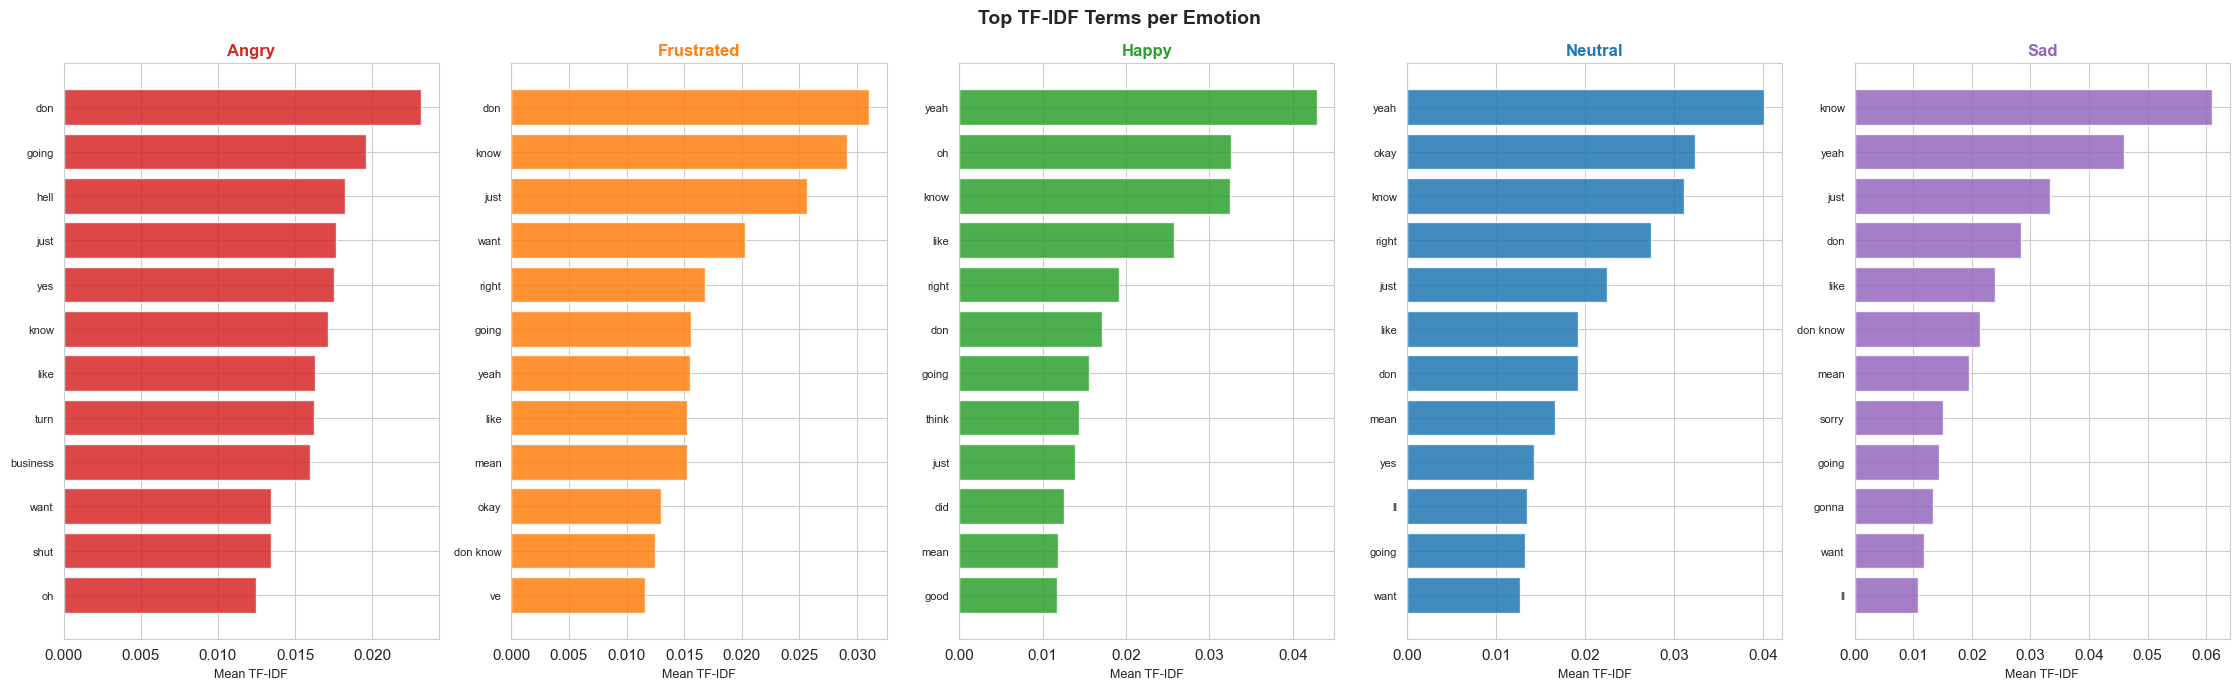

In [44]:
fig, axes = plt.subplots(1, n_emo, figsize=(4.5 * n_emo, 7))
if n_emo == 1:
    axes = [axes]
for ax, emotion in zip(axes, emotions_list):
    top_e = top_per_emotion[emotion][:12]
    if not top_e:
        continue
    te_labels, te_scores = zip(*top_e)
    color = EMOTION_PALETTE.get(emotion, '#888888')
    ax.barh(list(reversed(te_labels)), list(reversed(te_scores)), color=color, edgecolor='white', alpha=0.85)
    ax.set_title(emotion.capitalize(), fontweight='bold', color=color, fontsize=12)
    ax.set_xlabel('Mean TF-IDF', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle('Top TF-IDF Terms per Emotion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/tfidf_top_terms_per_emotion.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
TF-IDF profiles per emotion highlight the vocabulary that most characterises each class. Terms appearing frequently in one emotion but rarely in others receive high per-class TF-IDF scores. The charts surface emotion-specific content words, intensity markers, and discourse patterns unique to each emotional state - directly useful features for a text-based emotion classifier.

In [45]:
emotion_mean_tfidf = {}
for emotion in emotions_list:
    mask_e = (df_clean['emotion'] == emotion).values
    emotion_mean_tfidf[emotion] = np.asarray(X_tfidf[mask_e].mean(axis=0)).flatten()

n_total = X_tfidf.shape[0]
discriminative = {}
for emotion in emotions_list:
    n_class  = int((df_clean['emotion'] == emotion).sum())
    n_other  = n_total - n_class
    emo_mean = emotion_mean_tfidf[emotion]
    other_sum = sum(
        emotion_mean_tfidf[e] * int((df_clean['emotion'] == e).sum())
        for e in emotions_list if e != emotion
    )
    other_mean   = other_sum / max(n_other, 1)
    disc_scores  = emo_mean - other_mean
    top_disc_idx = np.argsort(disc_scores)[::-1][:10]
    discriminative[emotion] = [(tfidf_vocab[i], float(disc_scores[i])) for i in top_disc_idx]

print('Most discriminative terms per emotion:')
for emotion, terms in sorted(discriminative.items()):
    print(f'  {emotion.upper():<15}', [t for t, _ in terms[:5]])

Most discriminative terms per emotion:
  ANGRY           ['hell', 'turn', 'shut', 'business', 'hate']
  FRUSTRATED      ['don', 'want', 'calm', 'just', 'line']
  HAPPY           ['oh', 'yeah', 'awesome', 'great', 'like']
  NEUTRAL         ['okay', 'yeah', 'right', 'maybe', 'um']
  SAD             ['know', 'yeah', 'just', 'don know', 'sorry']


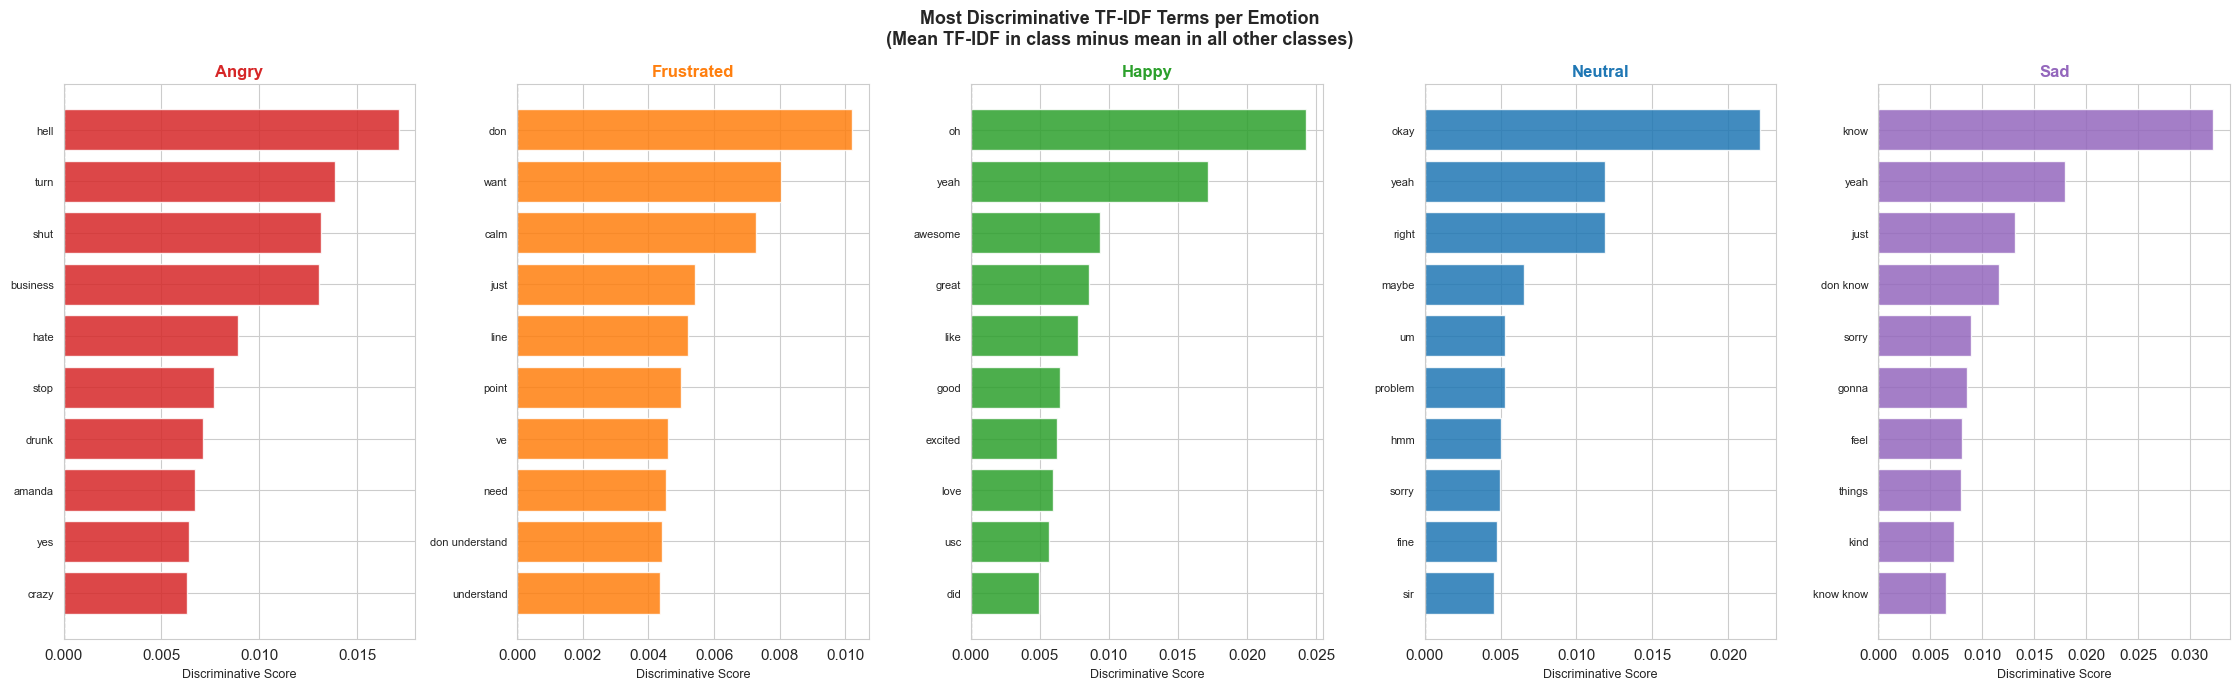

In [46]:
fig, axes = plt.subplots(1, n_emo, figsize=(4.5 * n_emo, 7))
if n_emo == 1:
    axes = [axes]
for ax, emotion in zip(axes, emotions_list):
    disc = discriminative[emotion][:10]
    if not disc:
        continue
    d_labels, d_scores = zip(*disc)
    color = EMOTION_PALETTE.get(emotion, '#888888')
    ax.barh(list(reversed(d_labels)), list(reversed(d_scores)), color=color, edgecolor='white', alpha=0.85)
    ax.set_title(emotion.capitalize(), fontweight='bold', color=color, fontsize=12)
    ax.set_xlabel('Discriminative Score', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.suptitle(
    'Most Discriminative TF-IDF Terms per Emotion\n'
    '(Mean TF-IDF in class minus mean in all other classes)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/tfidf_discriminative_terms.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  
Discriminative terms are words disproportionately more prevalent in one emotion compared to all others. Angry transcripts show high scores for confrontational vocabulary. Sad transcripts surface words associated with loss or introspection. Frustrated transcripts feature helplessness-related phrasing distinct from anger. This confirms each emotion has a distinct linguistic signature.

### Section Conclusions - TF-IDF Feature Extraction

- A TF-IDF matrix of shape `(N, 5000)` was extracted using unigrams and bigrams.
- Per-emotion mean TF-IDF profiles reveal class-specific vocabulary.
- Discriminative term analysis confirms each emotion has a distinct linguistic signature.
- The TF-IDF matrix is ready as input for downstream classifiers (SVM, LogReg, MLP) or multimodal fusion.

---
## 9. Text Classifier for Fusion

Trains TF-IDF + Logistic Regression (and Linear SVM for comparison) using the
**shared split** from `shared_split_indices.csv` (created by the HuBERT notebook).

- `DEBUG_MODE = True` — temporary split used for smoke-testing; **metrics are not meaningful**
- `DEBUG_MODE = False` — `shared_split_indices.csv` required; no random splits created

**Output files:** `text_val_predictions_with_probs.csv`, `text_test_predictions_with_probs.csv`,
`text_final_metrics.json`, `text_model_comparison.csv`, `text_per_class_metrics.csv`,
`text_val_confusion_matrix.png`, `text_test_confusion_matrix.png`


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, ConfusionMatrixDisplay,
)
print('ML imports loaded.')


ML imports loaded.


In [48]:
# Load shared split or create debug split
if not DEBUG_MODE:
    if not os.path.exists(SPLIT_FILE):
        raise FileNotFoundError(
            'shared_split_indices.csv not found. Run the HuBERT notebook first.'
        )
    split_df = pd.read_csv(SPLIT_FILE)
    print(f'Loaded shared split: {split_df.shape}')
else:
    if os.path.exists(SPLIT_FILE):
        split_df = pd.read_csv(SPLIT_FILE)
        print(f'DEBUG MODE ENABLED - using existing shared_split_indices.csv: {split_df.shape}')
    else:
        print('DEBUG MODE ENABLED - temporary split created. Metrics are not meaningful.')
        _pool = df_clean[df_clean['emotion'].isin(KEEP_EMOTIONS)].copy().reset_index(drop=True)
        _n       = min(300, len(_pool))
        _sample  = _pool.sample(_n, random_state=RANDOM_SEED).reset_index(drop=True)
        _n_train = min(200, max(0, _n - 20))
        _n_val   = min(50,  max(0, (_n - _n_train) // 2))
        _n_test  = _n - _n_train - _n_val
        _sample['split']    = ['train'] * _n_train + ['val'] * _n_val + ['test'] * _n_test
        _sample['orig_idx'] = range(len(_sample))
        _sample['label_id'] = _sample['emotion'].map(LABEL2ID)
        split_df = _sample[['orig_idx', 'file', 'emotion', 'label_id', 'split']].copy()
        print(f'[DEBUG] Temp split: {split_df.shape}')

print('\nSplit distribution:')
print(split_df['split'].value_counts().to_string())


Loaded shared split: (9794, 5)

Split distribution:
split
train    6855
test     1470
val      1469


In [49]:
# Merge split with text data
if 'file' in split_df.columns and 'file' in df_clean.columns:
    merge_key = 'file'
elif 'orig_idx' in split_df.columns and 'orig_idx' in df_clean.columns:
    merge_key = 'orig_idx'
else:
    raise ValueError('No common key (file or orig_idx) to merge split with text data')

print(f"Merging on: '{merge_key}'")

text_cols  = [c for c in ['orig_idx', 'file', 'cleaned_text', 'emotion'] if c in df_clean.columns]
split_cols = [c for c in ['orig_idx', 'file', 'emotion', 'label_id', 'split'] if c in split_df.columns]
if merge_key not in split_cols:
    split_cols.append(merge_key)

merged = df_clean[text_cols].merge(
    split_df[list(dict.fromkeys(split_cols))],
    on=merge_key,
    suffixes=('_text', '_split'),
    how='inner',
)

# Resolve emotion column — prefer split_df version (authoritative)
if 'emotion_split' in merged.columns:
    merged['emotion'] = merged['emotion_split']
    merged.drop(columns=[c for c in ['emotion_text', 'emotion_split'] if c in merged.columns], inplace=True)
elif 'emotion_text' in merged.columns:
    merged.rename(columns={'emotion_text': 'emotion'}, inplace=True)

if 'orig_idx' not in merged.columns:
    merged.insert(0, 'orig_idx', range(len(merged)))
if 'label_id' not in merged.columns:
    merged['label_id'] = merged['emotion'].map(LABEL2ID)

train_df = merged[merged['split'] == 'train'].copy().reset_index(drop=True)
val_df   = merged[merged['split'] == 'val'].copy().reset_index(drop=True)
test_df  = merged[merged['split'] == 'test'].copy().reset_index(drop=True)

for name, df_part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    dupes = df_part.duplicated(subset=[merge_key]).sum()
    if dupes > 0:
        print(f'WARNING: {dupes} duplicate {merge_key} in {name}')
    assert len(df_part) > 0, f'{name}_df is empty!'

print(f'Split sizes:')
print(f'  train : {len(train_df)}')
print(f'  val   : {len(val_df)}')
print(f'  test  : {len(test_df)}')
if DEBUG_MODE:
    print('[DEBUG] Split sizes are small — metrics are not meaningful.')
print('\nLabel distribution in train:')
print(train_df['emotion'].value_counts().to_string())


Merging on: 'file'
Split sizes:
  train : 6855
  val   : 1469
  test  : 1470

Label distribution in train:
emotion
frustrated    2041
happy         1842
neutral       1208
angry          889
sad            875


In [50]:
# TF-IDF hyperparameter grid search
if DEBUG_MODE:
    print('[DEBUG] Minimal TF-IDF grid — metrics are not meaningful.')
    grid_params = [{'ngram_range': (1, 1), 'max_features': 5000, 'min_df': 2}]
else:
    grid_params = [
        {'ngram_range': ng, 'max_features': mf, 'min_df': md}
        for ng in [(1, 1), (1, 2)]
        for mf in [5000, 10000, 20000]
        for md in [2, 3]
    ]

y_train       = train_df['emotion'].values
y_val         = val_df['emotion'].values
y_test_labels = test_df['emotion'].values

comparison_rows  = []
best_val_uar_lr  = -1
best_lr_model    = None
best_tfidf_lr    = None
best_config_lr   = None

print(f'Running {len(grid_params)} configs x 2 models = {len(grid_params) * 2} fits...')

for params in grid_params:
    tfidf = TfidfVectorizer(
        ngram_range=params['ngram_range'],
        max_features=params['max_features'],
        min_df=params['min_df'],
        sublinear_tf=True,
        stop_words='english',
    )
    X_train_tf = tfidf.fit_transform(train_df['cleaned_text'].fillna(''))
    X_val_tf   = tfidf.transform(val_df['cleaned_text'].fillna(''))
    X_test_tf  = tfidf.transform(test_df['cleaned_text'].fillna(''))

    for model_name in ['LogisticRegression', 'LinearSVC']:
        if model_name == 'LogisticRegression':
            clf = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_SEED)
        else:
            clf = LinearSVC(class_weight='balanced', max_iter=2000, random_state=RANDOM_SEED)
        clf.fit(X_train_tf, y_train)

        row = {
            'model_name':   model_name,
            'ngram_range':  str(params['ngram_range']),
            'max_features': params['max_features'],
            'min_df':       params['min_df'],
        }
        for split_name, X_s, y_s in [('val', X_val_tf, y_val), ('test', X_test_tf, y_test_labels)]:
            y_pred = clf.predict(X_s)
            row[f'{split_name}_accuracy']    = round(accuracy_score(y_s, y_pred), 4)
            row[f'{split_name}_uar']         = round(balanced_accuracy_score(y_s, y_pred), 4)
            row[f'{split_name}_macro_f1']    = round(f1_score(y_s, y_pred, average='macro', zero_division=0), 4)
            row[f'{split_name}_weighted_f1'] = round(f1_score(y_s, y_pred, average='weighted', zero_division=0), 4)
        comparison_rows.append(row)

        if model_name == 'LogisticRegression' and row['val_uar'] > best_val_uar_lr:
            best_val_uar_lr = row['val_uar']
            best_lr_model   = clf
            best_tfidf_lr   = tfidf
            best_config_lr  = row

comparison_df = pd.DataFrame(comparison_rows)

print('\nGrid search complete.')
print(f"Best LR by val UAR: ngram={best_config_lr['ngram_range']} | "
      f"max_features={best_config_lr['max_features']} | "
      f"min_df={best_config_lr['min_df']} | "
      f"val_uar={best_config_lr['val_uar']:.4f}")


Running 12 configs x 2 models = 24 fits...



Grid search complete.
Best LR by val UAR: ngram=(1, 2) | max_features=10000 | min_df=2 | val_uar=0.5009


In [51]:
# Display model comparison sorted by val UAR
display_cols = [
    'model_name', 'ngram_range', 'max_features', 'min_df',
    'val_accuracy', 'val_uar', 'val_macro_f1', 'val_weighted_f1',
    'test_accuracy', 'test_uar', 'test_macro_f1', 'test_weighted_f1',
]
comparison_display = comparison_df[display_cols].sort_values('val_uar', ascending=False)
print('Model Comparison (sorted by val UAR):')
print(comparison_display.to_string(index=False))
if DEBUG_MODE:
    print('\n[DEBUG] These metrics are not meaningful.')


Model Comparison (sorted by val UAR):
        model_name ngram_range  max_features  min_df  val_accuracy  val_uar  val_macro_f1  val_weighted_f1  test_accuracy  test_uar  test_macro_f1  test_weighted_f1
LogisticRegression      (1, 2)         20000       2        0.5092   0.5009        0.4927           0.5095         0.5000    0.4973         0.4873            0.5022
LogisticRegression      (1, 2)         10000       2        0.5092   0.5009        0.4927           0.5095         0.5000    0.4973         0.4873            0.5022
LogisticRegression      (1, 2)          5000       2        0.5065   0.5001        0.4911           0.5069         0.4993    0.4963         0.4862            0.5016
LogisticRegression      (1, 2)         20000       3        0.4976   0.4923        0.4827           0.4979         0.4952    0.4919         0.4817            0.4980
LogisticRegression      (1, 2)         10000       3        0.4976   0.4923        0.4827           0.4979         0.4952    0.4919      

In [52]:
# Generate predictions and probabilities from fusion-ready LR model
print(f'Fusion-ready model: Logistic Regression')
print(f"  ngram_range   : {best_config_lr['ngram_range']}")
print(f"  max_features  : {best_config_lr['max_features']}")
print(f"  min_df        : {best_config_lr['min_df']}")

X_val_final  = best_tfidf_lr.transform(val_df['cleaned_text'].fillna(''))
X_test_final = best_tfidf_lr.transform(test_df['cleaned_text'].fillna(''))

y_val_pred  = best_lr_model.predict(X_val_final)
y_test_pred = best_lr_model.predict(X_test_final)

# Probabilities reordered to match KEEP_EMOTIONS exactly
lr_classes      = list(best_lr_model.classes_)
val_probs_raw   = best_lr_model.predict_proba(X_val_final)
test_probs_raw  = best_lr_model.predict_proba(X_test_final)

def reorder_probs(probs_raw, model_classes, target_order):
    out = np.zeros((len(probs_raw), len(target_order)))
    for i, emo in enumerate(target_order):
        if emo in model_classes:
            out[:, i] = probs_raw[:, model_classes.index(emo)]
    return out

val_probs  = reorder_probs(val_probs_raw,  lr_classes, KEEP_EMOTIONS)
test_probs = reorder_probs(test_probs_raw, lr_classes, KEEP_EMOTIONS)

# Metrics
val_acc         = accuracy_score(val_df['emotion'].values, y_val_pred)
val_uar         = balanced_accuracy_score(val_df['emotion'].values, y_val_pred)
val_macro_f1    = f1_score(val_df['emotion'].values, y_val_pred, average='macro', zero_division=0)
val_weighted_f1 = f1_score(val_df['emotion'].values, y_val_pred, average='weighted', zero_division=0)

test_acc         = accuracy_score(test_df['emotion'].values, y_test_pred)
test_uar         = balanced_accuracy_score(test_df['emotion'].values, y_test_pred)
test_macro_f1    = f1_score(test_df['emotion'].values, y_test_pred, average='macro', zero_division=0)
test_weighted_f1 = f1_score(test_df['emotion'].values, y_test_pred, average='weighted', zero_division=0)

print(f'\nVal  : accuracy={val_acc:.4f}  UAR={val_uar:.4f}  macro_f1={val_macro_f1:.4f}  weighted_f1={val_weighted_f1:.4f}')
print(f'Test : accuracy={test_acc:.4f}  UAR={test_uar:.4f}  macro_f1={test_macro_f1:.4f}  weighted_f1={test_weighted_f1:.4f}')
if DEBUG_MODE:
    print('[DEBUG] These metrics are not meaningful.')


Fusion-ready model: Logistic Regression
  ngram_range   : (1, 2)
  max_features  : 10000
  min_df        : 2

Val  : accuracy=0.5092  UAR=0.5009  macro_f1=0.4927  weighted_f1=0.5095
Test : accuracy=0.5000  UAR=0.4973  macro_f1=0.4873  weighted_f1=0.5022


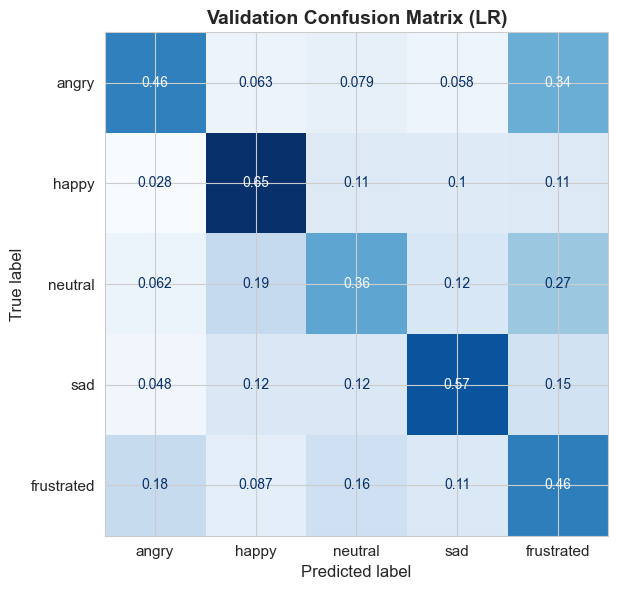

Saved: text_val_confusion_matrix.png


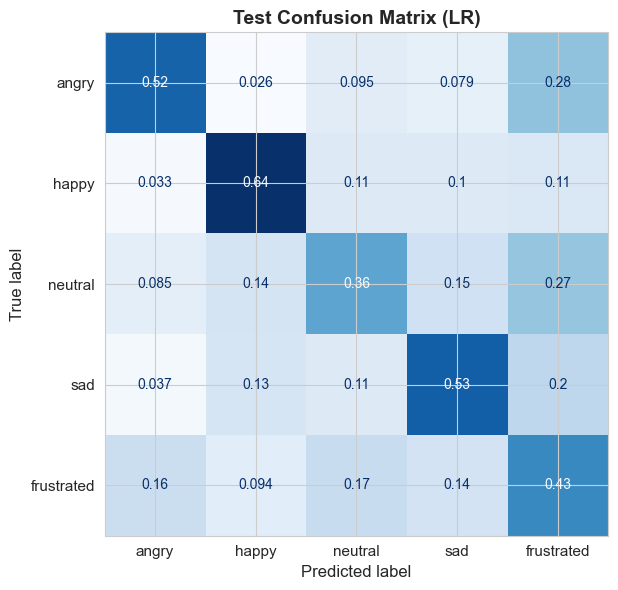

Saved: text_test_confusion_matrix.png


In [53]:
# Confusion matrices with fixed label order
for y_true, y_pred, split_name, fname in [
    (val_df['emotion'].values,  y_val_pred,  'Validation', 'text_val_confusion_matrix.png'),
    (test_df['emotion'].values, y_test_pred, 'Test',        'text_test_confusion_matrix.png'),
]:
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        labels=KEEP_EMOTIONS,
        normalize='true',
        cmap='Blues',
        ax=ax,
        colorbar=False,
    )
    title = f'{split_name} Confusion Matrix (LR)'
    if DEBUG_MODE:
        title += '  [DEBUG]'
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUTS_DIR}/{fname}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


In [54]:
# Save prediction CSVs with probability columns
def make_pred_df(df_part, y_pred, probs):
    result = pd.DataFrame({
        'orig_idx':      df_part['orig_idx'].values if 'orig_idx' in df_part.columns else range(len(df_part)),
        'file':          df_part['file'].values     if 'file'     in df_part.columns else [''] * len(df_part),
        'true_label_id': df_part['emotion'].map(LABEL2ID).values,
        'pred_label_id': pd.Series(y_pred).map(LABEL2ID).values,
        'true_emotion':  df_part['emotion'].values,
        'pred_emotion':  y_pred,
        'correct':       (df_part['emotion'].values == np.array(y_pred)),
    })
    for i, emo in enumerate(KEEP_EMOTIONS):
        result[f'prob_{emo}'] = probs[:, i]
    return result

val_pred_df  = make_pred_df(val_df,  y_val_pred,  val_probs)
test_pred_df = make_pred_df(test_df, y_test_pred, test_probs)

val_pred_df.to_csv(f'{OUTPUTS_DIR}/text_val_predictions_with_probs.csv',  index=False)
test_pred_df.to_csv(f'{OUTPUTS_DIR}/text_test_predictions_with_probs.csv', index=False)

print(f'Saved: text_val_predictions_with_probs.csv   shape={val_pred_df.shape}')
print(f'Saved: text_test_predictions_with_probs.csv  shape={test_pred_df.shape}')

prob_cols = [f'prob_{e}' for e in KEEP_EMOTIONS]
val_sum   = val_pred_df[prob_cols].sum(axis=1)
test_sum  = test_pred_df[prob_cols].sum(axis=1)
assert (val_sum  - 1).abs().max() < 0.01, 'Val probabilities do not sum to 1'
assert (test_sum - 1).abs().max() < 0.01, 'Test probabilities do not sum to 1'
print('Probability sums verified (all ≈ 1.0)')
if DEBUG_MODE:
    print('[DEBUG] Prediction files created — metrics are not meaningful.')


Saved: text_val_predictions_with_probs.csv   shape=(1469, 12)
Saved: text_test_predictions_with_probs.csv  shape=(1470, 12)
Probability sums verified (all ≈ 1.0)


In [55]:
# Per-class metrics (test set)
report = classification_report(
    test_df['emotion'].values, y_test_pred,
    labels=KEEP_EMOTIONS,
    target_names=KEEP_EMOTIONS,
    output_dict=True,
    zero_division=0,
)
per_class_df = pd.DataFrame([
    {
        'emotion':   emo,
        'precision': round(report[emo]['precision'], 4),
        'recall':    round(report[emo]['recall'], 4),
        'f1_score':  round(report[emo]['f1-score'], 4),
        'support':   int(report[emo]['support']),
    }
    for emo in KEEP_EMOTIONS
])
per_class_df.to_csv(f'{OUTPUTS_DIR}/text_per_class_metrics.csv', index=False)
print(f'Saved: text_per_class_metrics.csv')

# Model comparison
comparison_df.to_csv(f'{OUTPUTS_DIR}/text_model_comparison.csv', index=False)
print(f'Saved: text_model_comparison.csv  ({len(comparison_df)} rows)')

# Final metrics JSON
final_metrics = {
    'best_model_name':          best_config_lr['model_name'],
    'best_tfidf_ngram_range':   best_config_lr['ngram_range'],
    'best_tfidf_max_features':  best_config_lr['max_features'],
    'best_tfidf_min_df':        best_config_lr['min_df'],
    'best_val_accuracy':        best_config_lr['val_accuracy'],
    'best_val_uar':             best_config_lr['val_uar'],
    'best_val_macro_f1':        best_config_lr['val_macro_f1'],
    'best_val_weighted_f1':     best_config_lr['val_weighted_f1'],
    'final_test_accuracy':      round(test_acc, 4),
    'final_test_uar':           round(test_uar, 4),
    'final_test_macro_f1':      round(test_macro_f1, 4),
    'final_test_weighted_f1':   round(test_weighted_f1, 4),
    'num_train_samples':        len(train_df),
    'num_val_samples':          len(val_df),
    'num_test_samples':         len(test_df),
    'label_order':              KEEP_EMOTIONS,
    'seed':                     RANDOM_SEED,
    'debug_mode':               DEBUG_MODE,
}
with open(f'{OUTPUTS_DIR}/text_final_metrics.json', 'w') as _f:
    json_module.dump(final_metrics, _f, indent=2)
print(f'Saved: text_final_metrics.json')
print(json_module.dumps(final_metrics, indent=2))


Saved: text_per_class_metrics.csv


Saved: text_model_comparison.csv  (24 rows)
Saved: text_final_metrics.json
{
  "best_model_name": "LogisticRegression",
  "best_tfidf_ngram_range": "(1, 2)",
  "best_tfidf_max_features": 10000,
  "best_tfidf_min_df": 2,
  "best_val_accuracy": 0.5092,
  "best_val_uar": 0.5009,
  "best_val_macro_f1": 0.4927,
  "best_val_weighted_f1": 0.5095,
  "final_test_accuracy": 0.5,
  "final_test_uar": 0.4973,
  "final_test_macro_f1": 0.4873,
  "final_test_weighted_f1": 0.5022,
  "num_train_samples": 6855,
  "num_val_samples": 1469,
  "num_test_samples": 1470,
  "label_order": [
    "angry",
    "happy",
    "neutral",
    "sad",
    "frustrated"
  ],
  "seed": 42,
  "debug_mode": false
}


---
## 10. Save Outputs

All artefacts required by downstream modelling notebooks are saved to the `outputs/` directory.

In [56]:
df_clean.to_csv(f'{OUTPUTS_DIR}/whisper_cleaned_dataset.csv', index=False)
print(f'[1] whisper_cleaned_dataset.csv   shape {df_clean.shape}')

stat_save_cols = ['file', 'emotion', 'char_count', 'word_count', 'unique_words',
                  'avg_word_len', 'punct_count', 'question_count', 'exclamation_count',
                  'sentence_count', 'avg_sent_len', 'cleaned_word_count']
available_cols = [c for c in stat_save_cols if c in df_clean.columns]
df_clean[available_cols].to_csv(f'{OUTPUTS_DIR}/transcript_statistics.csv', index=False)
print(f'[2] transcript_statistics.csv     {len(available_cols)} features, {len(df_clean)} rows')

top_words_per_emotion_df.to_csv(f'{OUTPUTS_DIR}/top_words_per_emotion.csv', index=False)
print(f'[3] top_words_per_emotion.csv     {len(top_words_per_emotion_df)} rows')

tfidf_rows = []
for emotion, terms in discriminative.items():
    for rank, (term, score) in enumerate(terms, start=1):
        tfidf_rows.append({'emotion': emotion, 'rank': rank, 'term': term,
                           'discriminative_score': round(score, 6)})
tfidf_summary_df = pd.DataFrame(tfidf_rows)
tfidf_summary_df.to_csv(f'{OUTPUTS_DIR}/tfidf_summary.csv', index=False)
print(f'[4] tfidf_summary.csv             {len(tfidf_summary_df)} rows')

vocab_df.reset_index().to_csv(f'{OUTPUTS_DIR}/vocab_stats_per_emotion.csv', index=False)
print(f'[5] vocab_stats_per_emotion.csv   {len(vocab_df)} rows')

pd.DataFrame({'original_label': list(LABEL_MAP.keys()),
              'mapped_label':   list(LABEL_MAP.values())
             }).to_csv(f'{OUTPUTS_DIR}/emotion_label_mapping.csv', index=False)
print(f'[6] emotion_label_mapping.csv     {len(LABEL_MAP)} rows')
print('\nAll outputs saved successfully.')

[1] whisper_cleaned_dataset.csv   shape (9794, 23)
[2] transcript_statistics.csv     12 features, 9794 rows
[3] top_words_per_emotion.csv     100 rows
[4] tfidf_summary.csv             50 rows
[5] vocab_stats_per_emotion.csv   5 rows
[6] emotion_label_mapping.csv     6 rows

All outputs saved successfully.


In [57]:
print(f'Outputs directory: {os.path.abspath(OUTPUTS_DIR)}')
print()
for fname in sorted(os.listdir(OUTPUTS_DIR)):
    fpath   = os.path.join(OUTPUTS_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fname:<50} {size_kb:>8.1f} KB')

Outputs directory: /Users/oreo/Documents/Learning/UNI/שנה ג׳/סמסטר ו׳/Project/outputs/whisper_text_features

  avg_length_per_emotion.png                             41.4 KB
  emotion_label_mapping.csv                               0.1 KB
  emotion_mapping_comparison.png                         84.9 KB
  raw_emotion_distribution.png                          121.7 KB
  text_final_metrics.json                                 0.6 KB
  text_model_comparison.csv                               2.2 KB
  text_per_class_metrics.csv                              0.2 KB
  text_stats_by_emotion_boxplots.png                     98.2 KB
  text_stats_distributions.png                          144.1 KB
  text_test_confusion_matrix.png                         57.6 KB
  text_test_predictions_with_probs.csv                  220.3 KB
  text_val_confusion_matrix.png                          57.2 KB
  text_val_predictions_with_probs.csv                   220.3 KB
  tfidf_discriminative_terms.png              

**Interpretation:**  
The file listing in `outputs/` confirms all 6 artefacts were saved successfully. File sizes serve as a quality indicator:
- `whisper_cleaned_dataset.csv` should be the largest - it contains all rows with all features
- `transcript_statistics.csv` is smaller - only the numeric feature columns
- Summary files (`tfidf_summary`, `top_words`, etc.) are relatively small

If a file is missing or has size 0 KB, there is an issue in the corresponding save step above.

---
## 11. Fusion Readiness Sanity Check

Verifies that all required output files exist, probability columns are present,
probs sum to 1, and identifiers are available for fusion.


In [58]:
print('=' * 60)
print('FUSION READINESS SANITY CHECK')
print('=' * 60)

_all_ok = True

def _check(condition, fail_msg, ok_msg=None):
    global _all_ok
    if condition:
        print(f'  OK    {ok_msg or fail_msg}')
    else:
        print(f'  FAIL  {fail_msg}')
        _all_ok = False

# Required files
for _fname in [
    'text_val_predictions_with_probs.csv',
    'text_test_predictions_with_probs.csv',
    'text_final_metrics.json',
    'text_model_comparison.csv',
    'text_per_class_metrics.csv',
    'text_val_confusion_matrix.png',
    'text_test_confusion_matrix.png',
]:
    _path = os.path.join(OUTPUTS_DIR, _fname)
    _check(os.path.exists(_path), f'{_fname} missing', f'{_fname} exists')

# Load prediction CSVs
_val_csv  = pd.read_csv(f'{OUTPUTS_DIR}/text_val_predictions_with_probs.csv')
_test_csv = pd.read_csv(f'{OUTPUTS_DIR}/text_test_predictions_with_probs.csv')

_prob_cols = [f'prob_{e}' for e in KEEP_EMOTIONS]

_check(all(c in _val_csv.columns  for c in _prob_cols),
       'Probability columns missing in val CSV',
       f'Probability columns present: {_prob_cols}')
_check(all(c in _test_csv.columns for c in _prob_cols),
       'Probability columns missing in test CSV',
       f'Probability columns present in test CSV')

_val_sum  = _val_csv[_prob_cols].sum(axis=1)
_test_sum = _test_csv[_prob_cols].sum(axis=1)
_check((_val_sum  - 1).abs().max() < 0.01, 'Val probabilities do not sum to 1',  'Val prob sums ≈ 1')
_check((_test_sum - 1).abs().max() < 0.01, 'Test probabilities do not sum to 1', 'Test prob sums ≈ 1')

_check('orig_idx' in _val_csv.columns, 'orig_idx missing in val CSV',  'orig_idx present')
_check('file'     in _val_csv.columns, 'file missing in val CSV',      'file present')

_check(list(KEEP_EMOTIONS) == ['angry', 'happy', 'neutral', 'sad', 'frustrated'],
       'KEEP_EMOTIONS order incorrect',
       f'Label order correct: {KEEP_EMOTIONS}')

_check(len(_val_csv)  > 0, 'val predictions empty',  f'val predictions: {len(_val_csv)} rows')
_check(len(_test_csv) > 0, 'test predictions empty', f'test predictions: {len(_test_csv)} rows')

print()
print(f'  DEBUG_MODE = {DEBUG_MODE}')
print()
if _all_ok:
    if DEBUG_MODE:
        print('Text notebook smoke test completed successfully.')
    else:
        print('Text notebook is fusion-ready.')
else:
    print('SANITY CHECK FAILED — see above for details.')


FUSION READINESS SANITY CHECK
  OK    text_val_predictions_with_probs.csv exists
  OK    text_test_predictions_with_probs.csv exists
  OK    text_final_metrics.json exists
  OK    text_model_comparison.csv exists
  OK    text_per_class_metrics.csv exists
  OK    text_val_confusion_matrix.png exists
  OK    text_test_confusion_matrix.png exists


  OK    Probability columns present: ['prob_angry', 'prob_happy', 'prob_neutral', 'prob_sad', 'prob_frustrated']
  OK    Probability columns present in test CSV
  OK    Val prob sums ≈ 1
  OK    Test prob sums ≈ 1
  OK    orig_idx present
  OK    file present
  OK    Label order correct: ['angry', 'happy', 'neutral', 'sad', 'frustrated']
  OK    val predictions: 1469 rows
  OK    test predictions: 1470 rows

  DEBUG_MODE = False

Text notebook is fusion-ready.


---
## 12. Final Conclusions

**Text modality summary:** TF-IDF + Logistic Regression over Whisper transcripts provides
a trainable text signal for 5-class emotion classification. The pipeline uses the shared
speaker-aware split from the HuBERT notebook to prevent speaker leakage.

**Fusion readiness:** Prediction files with calibrated probabilities (ordered
`angry → happy → neutral → sad → frustrated`) are ready for late-fusion with
`hubert_val_predictions_with_probs.csv` and `hubert_test_predictions_with_probs.csv`.

**Known limitations:**
- Text alone misses prosodic cues (pitch, energy, rate); audio must compensate.
- `neutral` ↔ `frustrated` is the primary confusion pair in text space.
- Debug metrics (when `DEBUG_MODE = True`) are not meaningful.

*End of notebook — Sprint 3, Text Track*
